In [1]:
## packages for cloud data intake: 
import s3fs
import fsspec

## packages for analysis
import pandas as pd
import xarray as xr
%config InlineBackend.figure_format = 'retina'
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import feature as cf
import cmocean
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
!pip install colormaps   #always need to install packages
import colormaps as cmaps
from dask import delayed
import rioxarray as rxr
import glob
from scipy.stats import pearsonr
from tqdm import tqdm

  Using cached colormaps-0.5.0-py3-none-any.whl.metadata (7.7 kB)
Using cached colormaps-0.5.0-py3-none-any.whl (688 kB)


In [2]:
## Load this helper function

def open_s3_xarray_ukesm(bucket, group, scenario, variable_name, partial_filename, anon=False):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys][:2]
    print(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    ds = xr.open_mfdataset(
        urls,
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds#.load()


## Load this helper function

def open_s3_xarray_waccm(bucket, group, scenario, variable_name, partial_filename, anon=False,anon1=True):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}.*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys]
    urls.sort()
    print(urls)
    print(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}*.nc")
    ds = [xr.open_mfdataset(
        [url],
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon1},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )[[var]] for url in urls]

    # print(ds)
    # ds[-1] = ds[-1].sel(time=slice("2080","2084"))
    
    ds = xr.concat(ds,dim='time')
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds


def cart_plot(axes,ix, ncols=3,nrows=3, rlon=-150,llon=-60,tlat=42,blat=15):
    axes.add_feature(cf.BORDERS,linewidth=0.2) #add features (boarders )
    axes.add_feature(cf.COASTLINE,linewidth=1,color='gray') #coastlines 
    gl=axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.01, linestyle='--') #create the map type with grids 
    axes.set_extent([llon,rlon,blat,tlat]) #set the extent of the map
    if ix%ncols ==0:
        
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False

    elif ix>=(ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True

    else:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False
    if ix == (ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True
    axes.xformatter = LONGITUDE_FORMATTER;  axes.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'color':'black','size':12} #change font style for x-axis 
    gl.ylabel_style = {'color':'black','size':12}#change font style for y-axis  

convert = lambda x: chr(ord('`')+(x+1)) if x<26 else chr(ord('`')+((x)//25))+chr(ord('`')+(x+1)%26)

In [5]:
# Connect to AWS S3 storage and load WACCM historical Precipitation 
fs = s3fs.S3FileSystem(anon=True)

# load catalogue
df = pd.read_csv("https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.csv")

# subset the archive
df_subset = df.query(
    "activity_id=='CMIP'& source_id=='CESM2-WACCM' & \
    experiment_id=='historical' & table_id=='Amon' & \
    variable_id=='ua'")

# get the path to a specific zarr store
zstores = df_subset.zstore.values
zstores.sort()

In [4]:
sorted(df.query(
    "activity_id=='CMIP'& source_id=='CESM2-WACCM' & \
    experiment_id=='historical' & table_id=='Amon'")['variable_id'].values)

['cfc11global',
 'cfc12global',
 'ch4',
 'ch4',
 'ch4',
 'ci',
 'cl',
 'cl',
 'cl',
 'cli',
 'cli',
 'cli',
 'clivi',
 'clivi',
 'clivi',
 'clt',
 'clt',
 'clt',
 'clw',
 'clw',
 'clw',
 'clwvi',
 'clwvi',
 'clwvi',
 'co2',
 'co2',
 'co2',
 'co2mass',
 'evspsbl',
 'evspsbl',
 'evspsbl',
 'hfls',
 'hfls',
 'hfls',
 'hfss',
 'hfss',
 'hfss',
 'hur',
 'hur',
 'hur',
 'hurs',
 'hurs',
 'hurs',
 'hus',
 'hus',
 'hus',
 'huss',
 'huss',
 'huss',
 'n2o',
 'n2oglobal',
 'o3',
 'o3',
 'o3',
 'pr',
 'pr',
 'pr',
 'prc',
 'prc',
 'prc',
 'prw',
 'prw',
 'prw',
 'ps',
 'ps',
 'ps',
 'psl',
 'psl',
 'psl',
 'rlds',
 'rlds',
 'rlds',
 'rldscs',
 'rlus',
 'rlus',
 'rlus',
 'rlut',
 'rlut',
 'rlut',
 'rlutcs',
 'rlutcs',
 'rlutcs',
 'rsds',
 'rsds',
 'rsds',
 'rsdscs',
 'rsdt',
 'rsdt',
 'rsdt',
 'rsus',
 'rsus',
 'rsus',
 'rsuscs',
 'rsut',
 'rsut',
 'rsut',
 'rsutcs',
 'rsutcs',
 'rsutcs',
 'rtmt',
 'rtmt',
 'rtmt',
 'sbl',
 'sfcWind',
 'sfcWind',
 'sfcWind',
 'ta',
 'ta',
 'ta',
 'tas',
 'tas',
 't

In [5]:
np.unique(df_subset['table_id'].values)

array(['Amon'], dtype=object)

In [9]:
lon_slice = slice(-25, 25)
lat_slice = slice(0,35)
time_slice = slice("1981","2014")

In [7]:
!pip install "s3fs>=2024.3.0" "aiobotocore>=2.13.0"

In [10]:
lon_name = 'lon'
lat_name = 'lat'

_vars = ['ua','va','psl','ts','zg']

for var in tqdm(_vars, desc='Loading variables'):
    df_subset = df.query(
    f"activity_id=='CMIP'& source_id=='CESM2-WACCM' & \
    experiment_id=='historical' & table_id=='Amon' & \
    variable_id=='{var}'")

    # get the path to a specific zarr store
    zstores = df_subset.zstore.values
    zstores.sort()
    dds = []
    for zstore in zstores:
        
        _out = xr.open_dataset(
            zstore,
            engine="zarr",
            # consolidated=True,
            chunks={},                        # or {} / None or 'auto' as you prefer
            storage_options={"anon": True}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
            "time" : time_slice,
            lon_name : lon_slice, 
            lat_name : lat_slice})
        dds.append(_out.mean('nbnd'))
        
    DS = xr.concat(dds, dim='ensemble').mean('ensemble')
    locals()[f'waccm_hist_{var}'] =DS.sel(time=DS.time.dt.month.isin([6,7,8,9])).load()

Loading variables:   0%|          | 0/5 [00:00<?, ?it/s]

Loading variables:  20%|██        | 1/5 [00:27<01:49, 27.29s/it]

In [8]:
lon_name = 'lon'
lat_name = 'lat'

_vars = ['ua','va','psl','ts','zg']

for var in tqdm(_vars, desc='Loading variables'):
    df_subset = df.query(
    f"activity_id=='CMIP'& source_id=='UKESM1-0-LL' & \
    experiment_id=='historical' & table_id=='Amon' & \
    variable_id=='{var}'")

    # get the path to a specific zarr store
    zstores = df_subset.zstore.values
    zstores.sort()
    dds = []
    for zstore in zstores:
        
        _out = xr.open_dataset(
            zstore,
            engine="zarr",
            # consolidated=True,
            chunks={},                        # or {} / None or 'auto' as you prefer
            storage_options={"anon": True}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
            "time" : time_slice,
            lon_name : lon_slice, 
            lat_name : lat_slice})
        dds.append(_out.mean('bnds'))
        
    DS = xr.concat(dds, dim='ensemble').mean('ensemble')
    locals()[f'ukesm_hist_{var}'] =DS.sel(time=DS.time.dt.month.isin([6,7,8,9])).load()

Loading variables:   0%|          | 0/5 [00:00<?, ?it/s]

Loading variables:  20%|██        | 1/5 [01:20<05:21, 80.25s/it]

Loading variables:  40%|████      | 2/5 [02:46<04:11, 83.69s/it]

Loading variables:  60%|██████    | 3/5 [03:06<01:49, 54.79s/it]

Loading variables:  80%|████████  | 4/5 [03:28<00:41, 41.65s/it]

Loading variables: 100%|██████████| 5/5 [04:42<00:00, 53.24s/it]

Loading variables: 100%|██████████| 5/5 [04:42<00:00, 56.41s/it]

np.unique(df.query(
    f"activity_id=='CMIP'& source_id=='UKESM1-0-LL' & \
    experiment_id=='historical' & table_id=='Amon'")['variable_id'].values)

In [9]:
sim_time = slice("2035","2085")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

In [10]:
_vars = ['psl']
zstores = ['r12i1p1f2','r2i1p1f2','r3i1p1f2']

for var in _vars:
    dd = []
    for zstore in zstores:    
        _out = open_s3_xarray_ukesm(
            bucket=f"reflective-persistent-prod-large",
            group="UKESM1-1",
            scenario=f"G6-1p5K-HiLLA/{zstore}/ap5/Amon/{var}",
            variable_name=f"{var}",
            partial_filename=f"Amon_UKESM1-1-LL_g6-1p5-hilla_{zstore}_gn",
        ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)
        dd.append(_out)

    DS = xr.concat(dd, dim='ensemble').mean('ensemble')
    locals()[f'ukesm_{var}'] = DS.sel(time=DS.time.dt.month.isin([6,7,8,9])).load()


_vars = ['huss','tas','ts']
zstores = ['r12i1p1f2','r2i1p1f2','r3i1p1f2']

for var in _vars:
    dd = []
    for zstore in zstores:    
        _out = open_s3_xarray_ukesm(
            bucket=f"reflective-persistent-prod-large",
            group="UKESM1-1",
            scenario=f"G6-1p5K-HiLLA/{zstore}/apm/Amon/{var}",
            variable_name=f"{var}",
            partial_filename=f"Amon_UKESM1-1-LL_g6-1p5-hilla_{zstore}_gn",
        ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)
        dd.append(_out)

    DS = xr.concat(dd, dim='ensemble').mean('ensemble')
    locals()[f'ukesm_{var}'] = DS.sel(time=DS.time.dt.month.isin([6,7,8,9])).load()

_vars = ['ua','va']
zstores = ['r12i1p1f2','r2i1p1f2','r3i1p1f2']

for var in _vars:
    dd = []
    for zstore in zstores:    
        _out = open_s3_xarray_ukesm(
            bucket=f"reflective-persistent-prod-large",
            group="UKESM1-1",
            scenario=f"G6-1p5K-HiLLA/{zstore}/ap4/AERmon/{var}",
            variable_name=f"{var}",
            partial_filename=f"AERmon_UKESM1-1-LL_g6-1p5-hilla_{zstore}_gn",
        ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)
        dd.append(_out)

    DS = xr.concat(dd, dim='ensemble').mean('ensemble')
    locals()[f'ukesm_{var}'] = DS.sel(time=DS.time.dt.month.isin([6,7,8,9])).load()
    

reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r12i1p1f2/ap5/Amon/psl/psl_Amon_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn*.nc


/tmp/ipykernel_400/1076983059.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r2i1p1f2/ap5/Amon/psl/psl_Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn*.nc


/tmp/ipykernel_400/1076983059.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r3i1p1f2/ap5/Amon/psl/psl_Amon_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn*.nc


...

lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r2i1p1f2/ap4/AERmon/va/va_AERmon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn*.nc


/tmp/ipykernel_400/1076983059.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r3i1p1f2/ap4/AERmon/va/va_AERmon_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn*.nc


/tmp/ipykernel_400/1076983059.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(
/tmp/ipykernel_400/2390370896.py:53: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  DS = xr.concat(dd, dim='ensemble').mean('ensemble')


lat


In [11]:
sim_time = slice("2035","2084")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)
_vars = ['U','TS', 'V', 'PSL','Q']
_anons = [False, False, False, False,False]
zstores = ['r1','r2','r3']

for var,an  in tqdm(zip(_vars,_anons)):
    dd = []
    for zstore in zstores:
        print(zstore)
        _out = open_s3_xarray_waccm(
            bucket="reflective-persistent-prod-large",
            group="CESM2-WACCM",
            scenario="G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.",
            variable_name=var,
            partial_filename="",
            anon1=an
        ).sel( lon=_lon_slice, lat=_lat_slice)[[var]]
        
        dd.append(_out)
    DS = xr.concat(dd, dim='ensemble').mean('ensemble')
    locals()[f'waccm_{var}'] = DS.sel(time=DS.time.dt.month.isin([6,7,8,9])).load()

# waccm_e2 = open_s3_xarray_waccm(
#     bucket="reflective-persistent-prod-large",
#     group="CESM2-WACCM",
#     scenario="G6-1.5k-HiLLA/r2/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h1.",
#     variable_name="PRECT",
#     partial_filename="",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# waccm_e3 = open_s3_xarray_waccm(
#     bucket="reflective-persistent-prod-large",
#     group="CESM2-WACCM",
#     scenario="G6-1.5k-HiLLA/r3/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h1.",
#     variable_name="PRECT",
#     partial_filename="",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# ukesm_e1 = open_s3_xarray(
#     bucket="reflective-persistent-prod-large",
#     group="UKESM1-1",
#     scenario="G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr",
#     variable_name="pr",
#     partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

0it [00:00, ?it/s]

r1
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U*.nc


lat
r2
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U*.nc


lat
r3
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U*.nc


lat


...

r2
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.Q.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.Q.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.Q*.nc


lat
r3
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.Q.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.Q.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.Q*.nc


lat


5it [03:12, 38.81s/it]

5it [03:12, 38.51s/it]

/tmp/ipykernel_400/1433108780.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=2, h_pad=-5)


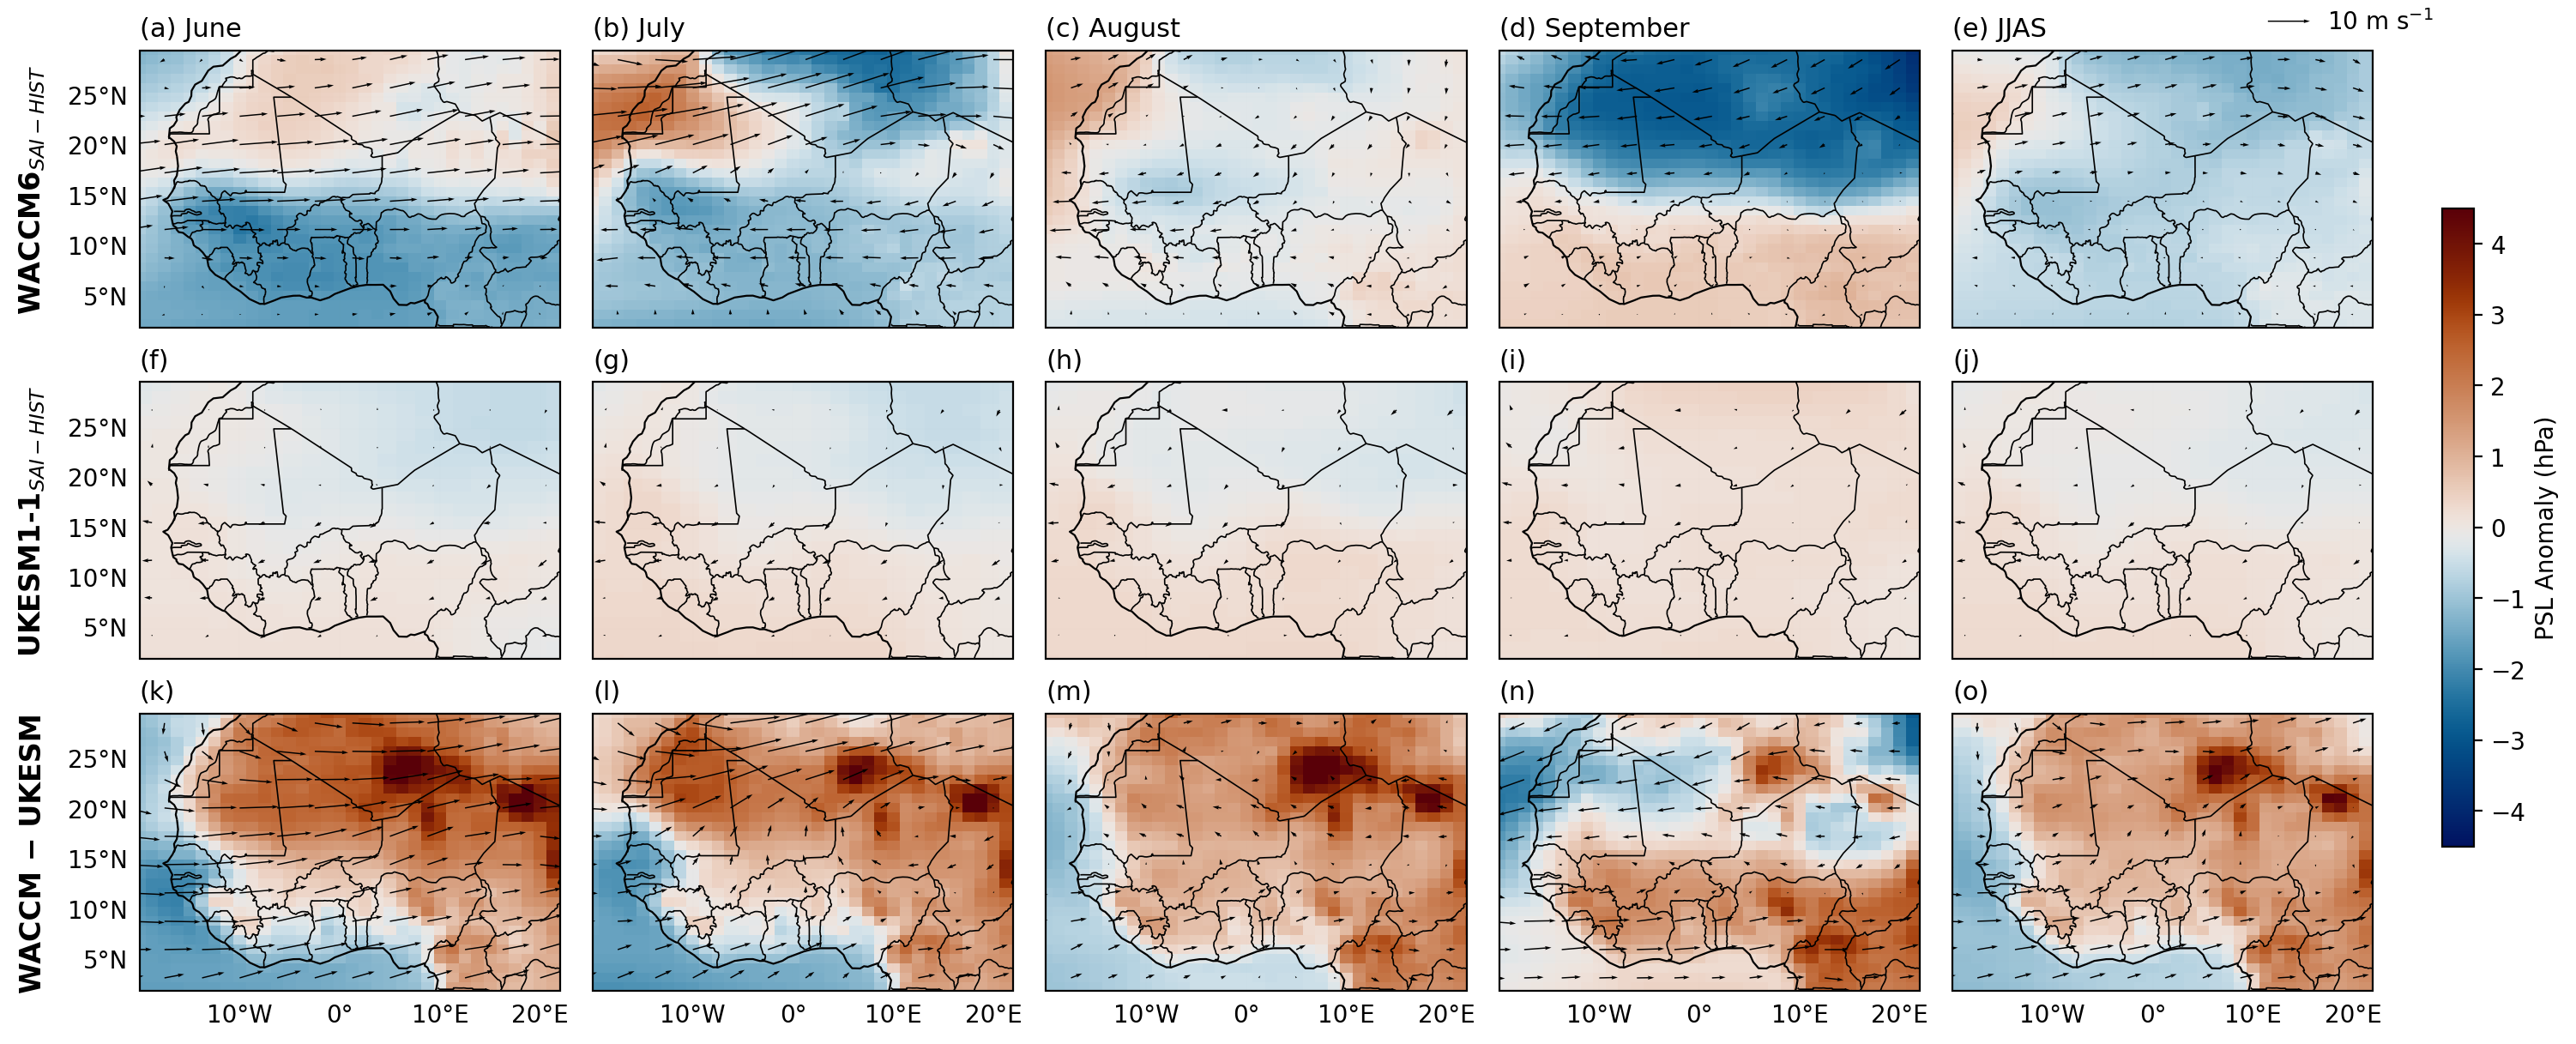

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import string
import calendar

mods = ['waccm','ukesm','diff']
sel_m = [[6],[7],[8],[9],[6,7,8,9]]

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3,
    ncols=len(sel_m),
    figsize=(16,7),
    subplot_kw={'projection': proj}
)

vmin = -4.50
vmax = 4.50
panel_ID = np.arange(0,15).reshape(3,5).T.reshape(1,15)
letters = list(string.ascii_lowercase)
panel = 0

for j, m in enumerate(sel_m):

    if len(m) == 1:
        mname = calendar.month_name[m[0]]
    else:
        mname = "JJAS"

    # -----------------------------
    # WACCM anomalies
    # -----------------------------
    psl_waccm = (
        waccm_PSL.sel(time=waccm_PSL.time.dt.month.isin(m))
        .mean('time')['PSL']
        -
        waccm_hist_psl.sel(time=waccm_hist_psl.time.dt.month.isin(m))
        .mean('time')['psl']
        .interp(lon=waccm_PSL.lon, lat=waccm_PSL.lat)
    )/100

    u_waccm = (
        waccm_U.sel(lev=500,time=waccm_U.time.dt.month.isin(m),method='nearest')
        .mean('time')['U']
        -
        waccm_hist_ua.sel(time=waccm_hist_ua.time.dt.month.isin(m),plev=50000,method='nearest')
        .mean('time')['ua']
        .interp(lon=waccm_PSL.lon, lat=waccm_PSL.lat)
    )

    v_waccm = (
        waccm_V.sel(lev=500,time=waccm_V.time.dt.month.isin(m),method='nearest')
        .mean('time')['V']
        -
        waccm_hist_va.sel(time=waccm_hist_va.time.dt.month.isin(m),plev=50000,method='nearest')
        .mean('time')['va']
        .interp(lon=waccm_PSL.lon, lat=waccm_PSL.lat)
    )

    # -----------------------------
    # UKESM anomalies
    # -----------------------------
    psl_ukesm = (
        ukesm_psl.sel(time=ukesm_psl.time.dt.month.isin(m))
        .mean('time')['psl']
        -
        ukesm_hist_psl.sel(time=ukesm_hist_psl.time.dt.month.isin(m))
        .mean('time')['psl']
        .interp(lon=ukesm_psl.lon, lat=ukesm_psl.lat)
    )/100

    u_ukesm = (
        ukesm_ua.sel(lev=5.036667e+03,time=ukesm_ua.time.dt.month.isin(m),method='nearest')
        .mean('time')['ua']
        -
        ukesm_hist_ua.sel(time=ukesm_hist_ua.time.dt.month.isin(m),plev=50000,method='nearest')
        .mean('time')['ua']
        .interp(lon=ukesm_ua.lon, lat=ukesm_ua.lat)
    )

    v_ukesm = (
        ukesm_va.sel(lev=5.036667e+03,time=ukesm_va.time.dt.month.isin(m),method='nearest')
        .mean('time')['va']
        -
        ukesm_hist_va.sel(time=ukesm_hist_va.time.dt.month.isin(m),plev=50000,method='nearest')
        .mean('time')['va']
        .interp(lon=ukesm_va.lon, lat=ukesm_va.lat)
    )

    # -----------------------------
    # Interpolate UKESM → WACCM grid
    # -----------------------------
    psl_ukesm_i = ukesm_psl.sel(time=ukesm_psl.time.dt.month.isin(m)).mean('time')['psl'].interp(lon=psl_waccm.lon, lat=psl_waccm.lat)
    u_ukesm_i   = ukesm_ua.sel(lev=5.036667e+03,time=ukesm_ua.time.dt.month.isin(m),method='nearest').mean('time')['ua'].interp(lon=u_waccm.lon, lat=u_waccm.lat)
    v_ukesm_i   = ukesm_va.sel(lev=5.036667e+03,time=ukesm_va.time.dt.month.isin(m),method='nearest').mean('time')['va'].interp(lon=v_waccm.lon, lat=v_waccm.lat)

    # -----------------------------
    # Difference
    # -----------------------------
    psl_diff = (waccm_PSL.sel(time=waccm_PSL.time.dt.month.isin(m)).mean('time')['PSL'] - psl_ukesm_i)/100
    u_diff   = waccm_U.sel(lev=500,time=waccm_U.time.dt.month.isin(m),method='nearest').mean('time')['U'] - u_ukesm_i
    v_diff   = waccm_V.sel(lev=500,time=waccm_V.time.dt.month.isin(m),method='nearest').mean('time')['V'] - v_ukesm_i

    fields = [
        (psl_waccm,u_waccm,v_waccm,'WACCM6$_{SAI-HIST}$'),
        (psl_ukesm,u_ukesm,v_ukesm,'UKESM1-1$_{SAI-HIST}$'),
        (psl_diff,u_diff,v_diff,'WACCM − UKESM')
    ]

    for i, (psl,u500,v500,label) in enumerate(fields):

        ax = axes[i,j]

        im = psl.plot(
            ax=ax,
            transform=proj,
            cmap=cmaps.vik,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False
        )

        skip = 3
        q = ax.quiver(
            u500.lon.values[::skip],
            u500.lat.values[::skip],
            u500.values[::skip, ::skip],
            v500.values[::skip, ::skip],
            transform=proj,
            scale=100,
            width=0.003
        )

        # -----------------------------
        # Map features
        # -----------------------------
        ax.coastlines(resolution='110m', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.6)
        ax.set_extent([-20,22,2,28])
        # -----------------------------
        # Gridlines and labels
        # -----------------------------
        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.004,
            linestyle='--',
            alpha=0.5
        )

        gl.top_labels = False
        gl.right_labels = False

        # Latitude labels only first row
        if j == 0:
            gl.left_labels = True
        else:
            gl.left_labels = False

        # Longitude labels only last row
        if i == 2:
            gl.bottom_labels = True
        else:
            gl.bottom_labels = False

        # -----------------------------
        # Titles
        # -----------------------------
        
        ax.set_title(f"({letters[panel_ID[0][panel]]}) {mname}", loc='left', fontsize=11) if i==0 else ax.set_title(f"({letters[panel_ID[0][panel]]})", loc='left', fontsize=11)

        if j == 0:
            ax.text(
                -0.22,0.5,label,
                transform=ax.transAxes,
                rotation=90,
                va='center',
                ha='right',
                fontsize=12,
                fontweight='bold'
            )

        panel += 1

# -----------------------------
# Colorbar
# -----------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='vertical',
    fraction=0.015,
    pad=-0.175
)
cbar.set_label("PSL Anomaly (hPa)")

# -----------------------------
# Quiver legend
# -----------------------------
plt.quiverkey(
    q,
    X=0.85,
    Y=3.5,
    U=10,
    label="10 m s$^{-1}$",
    labelpos='E'
)

plt.tight_layout(w_pad=2, h_pad=-5)
plt.savefig('Images/dynamics_psl_ws_500_v2.png', dpi=250, bbox_inches="tight")
plt.savefig('Images/dynamics_psl_ws_500_v2.pdf', bbox_inches="tight")
plt.show()

In [15]:
def compute_meridional_temp_gradient(tas, lat_name="lat", lon_name="lon", zonal_mean=False):
    """
    Compute the meridional gradient of surface temperature (∂T/∂y).

    Parameters
    ----------
    tas : xarray.DataArray
        Surface temperature with at least a latitude dimension.
        Expected dimensions: (..., lat, lon) or (..., lat)
    lat_name : str, optional
        Name of the latitude dimension (default is "lat").
    lon_name : str, optional
        Name of the longitude dimension (default is "lon").
    zonal_mean : bool, optional
        If True, returns the zonal mean meridional gradient (averaged over longitude).

    Returns
    -------
    dT_dy : xarray.DataArray
        Meridional temperature gradient in units of K m⁻¹.

        If `zonal_mean=True`, output dimensions will exclude longitude.
        Otherwise, output retains the same dimensions as input.

    Notes
    -----
    - The function first computes ∂T/∂lat (K per degree), then converts to ∂T/∂y (K per meter)
      using Earth's radius.
    - This quantity represents the north–south temperature gradient, which is a key driver of:
        * Monsoon circulation strength
        * Pressure gradients
        * Vertical wind shear (thermal wind balance)
    - In monsoon regions (e.g., West Africa), a weaker gradient often corresponds to weaker
      monsoon flow and reduced precipitation.
    """

    Re = 6.371e6  # Earth radius in meters

    # Compute dT/dlat (K per degree)
    dT_dlat = tas.differentiate(lat_name)

    # Convert latitude spacing to meters
    lat_rad = np.deg2rad(tas[lat_name])
    dy = np.gradient(lat_rad) * Re

    # Broadcast dy to match DataArray shape
    dy_xr = xr.DataArray(dy, coords={lat_name: tas[lat_name]}, dims=[lat_name])

    # Compute dT/dy (K per meter)
    dT_dy = dT_dlat / dy_xr

    # Optional zonal mean
    if zonal_mean and lon_name in tas.dims:
        dT_dy = dT_dy.mean(lon_name)

    return dT_dy

UKESM lon match: True
UKESM lat match: True
WACCM lon match: True
WACCM lat match: True
UKESM HIST years: 34
UKESM SAI years: 50
WACCM HIST years: 34
WACCM SAI years: 50


UKESM significant fraction: 0.7376373626373627
WACCM significant fraction: 0.8585164835164835


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_ar

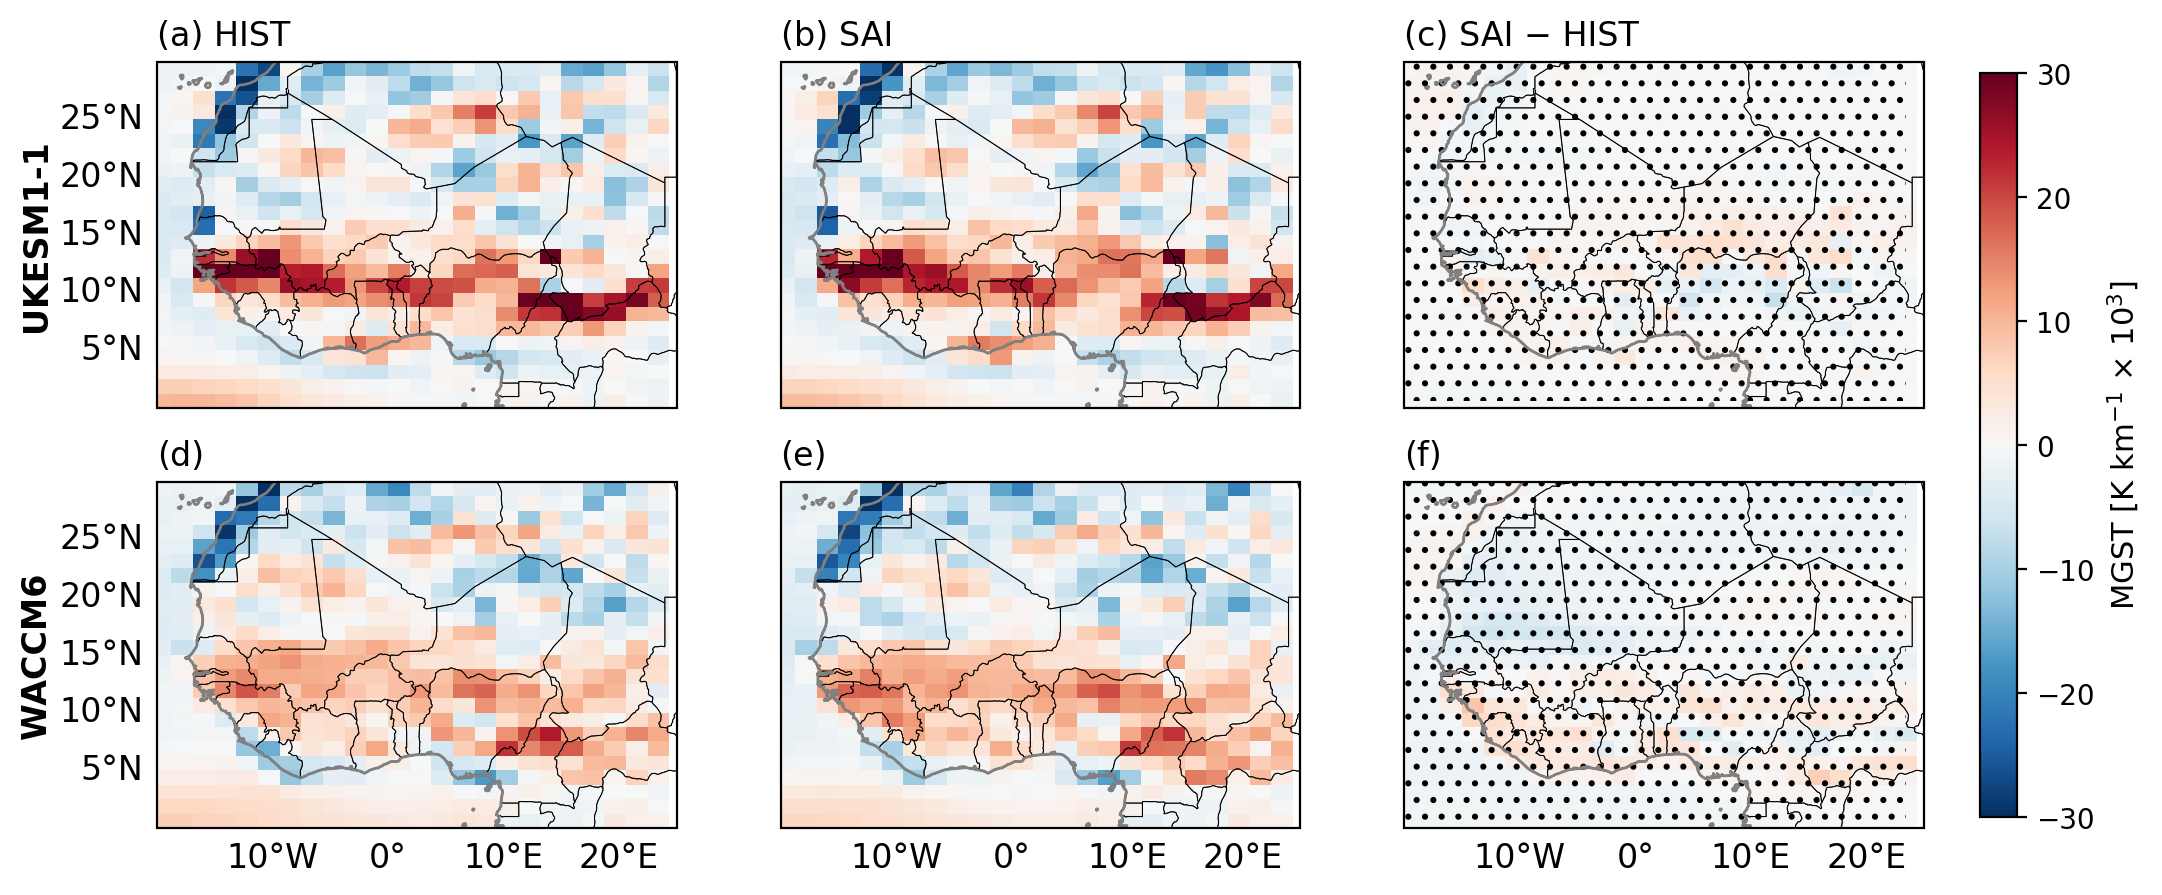

In [31]:
# ============================================================
# Meridional Temperature Gradient Analysis
# HIST, SAI, SAI-HIST + Statistical Significance
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import ttest_ind


# ============================================================
# Functions
# ============================================================

def normalize_longitude(da, lon_name="lon"):
    da = da.assign_coords({lon_name: ((da[lon_name] + 180) % 360) - 180})
    return da.sortby(lon_name)


def compute_meridional_temp_gradient(tas, lat_name="lat"):
    Re = 6.371e6
    dT_dlat = tas.differentiate(lat_name)
    return dT_dlat * 180.0 / (np.pi * Re)


def annual_mean(da, time_name="time"):
    return da.groupby(f"{time_name}.year").mean(time_name).rename({"year": "sample"})


def xr_welch_ttest(a, b, dim="sample"):
    a = a.rename({dim: "sample_a"})
    b = b.rename({dim: "sample_b"})

    def _ttest(x, y):
        x = x[np.isfinite(x)]
        y = y[np.isfinite(y)]
        if len(x) < 2 or len(y) < 2:
            return np.nan
        return ttest_ind(x, y, equal_var=False, alternative="two-sided").pvalue

    return xr.apply_ufunc(
        _ttest, a, b,
        input_core_dims=[["sample_a"], ["sample_b"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="exact"
    )


# ============================================================
# Extract temperature variables
# ============================================================

ukesm_hist_raw = normalize_longitude(ukesm_hist_ts["ts"])
ukesm_sai_raw  = normalize_longitude(ukesm_ts["ts"])

waccm_hist_raw = normalize_longitude(waccm_hist_ts["ts"])
waccm_sai_raw  = normalize_longitude(waccm_TS["TS"])


# ============================================================
# Compute time-varying meridional temperature gradients
# ============================================================

ukesm_hist_all = compute_meridional_temp_gradient(ukesm_hist_raw)
ukesm_sai_all  = compute_meridional_temp_gradient(ukesm_sai_raw)

waccm_hist_all = compute_meridional_temp_gradient(waccm_hist_raw)
waccm_sai_all  = compute_meridional_temp_gradient(waccm_sai_raw)


# ============================================================
# Put everything on one common grid
# ============================================================

ref_lat = ukesm_hist_all.lat
ref_lon = ukesm_hist_all.lon

ukesm_hist_all_i = ukesm_hist_all.assign_coords(lat=ref_lat, lon=ref_lon)
ukesm_sai_all_i  = ukesm_sai_all.interp(lat=ref_lat, lon=ref_lon).assign_coords(lat=ref_lat, lon=ref_lon)

waccm_hist_all_i = waccm_hist_all.interp(lat=ref_lat, lon=ref_lon).assign_coords(lat=ref_lat, lon=ref_lon)
waccm_sai_all_i  = waccm_sai_all.interp(lat=ref_lat, lon=ref_lon).assign_coords(lat=ref_lat, lon=ref_lon)


# ============================================================
# Check spatial alignment
# ============================================================

print("UKESM lon match:", np.array_equal(ukesm_hist_all_i.lon.values, ukesm_sai_all_i.lon.values))
print("UKESM lat match:", np.array_equal(ukesm_hist_all_i.lat.values, ukesm_sai_all_i.lat.values))

print("WACCM lon match:", np.array_equal(waccm_hist_all_i.lon.values, waccm_sai_all_i.lon.values))
print("WACCM lat match:", np.array_equal(waccm_hist_all_i.lat.values, waccm_sai_all_i.lat.values))


# ============================================================
# Climatological means
# ============================================================

ukesm_hist = ukesm_hist_all_i.mean("time")
ukesm_sai  = ukesm_sai_all_i.mean("time")

waccm_hist = waccm_hist_all_i.mean("time")
waccm_sai  = waccm_sai_all_i.mean("time")


# ============================================================
# SAI response
# ============================================================

ukesm_resp = ukesm_sai - ukesm_hist
waccm_resp = waccm_sai - waccm_hist


# ============================================================
# Annual means for significance testing
# ============================================================

ukesm_hist_annual = annual_mean(ukesm_hist_all_i)
ukesm_sai_annual  = annual_mean(ukesm_sai_all_i)

waccm_hist_annual = annual_mean(waccm_hist_all_i)
waccm_sai_annual  = annual_mean(waccm_sai_all_i)

print("UKESM HIST years:", ukesm_hist_annual.sizes["sample"])
print("UKESM SAI years:", ukesm_sai_annual.sizes["sample"])
print("WACCM HIST years:", waccm_hist_annual.sizes["sample"])
print("WACCM SAI years:", waccm_sai_annual.sizes["sample"])


# ============================================================
# Statistical significance
# ============================================================

alpha = 0.05

ukesm_p = xr_welch_ttest(ukesm_sai_annual, ukesm_hist_annual)
waccm_p = xr_welch_ttest(waccm_sai_annual, waccm_hist_annual)

ukesm_sig = ukesm_p < alpha
waccm_sig = waccm_p < alpha

print("UKESM significant fraction:", float(ukesm_sig.mean().values))
print("WACCM significant fraction:", float(waccm_sig.mean().values))


# ============================================================
# Convert K m^-1 -> K (1000 km)^-1
# ============================================================

scale = 1e6

ukesm_hist *= scale
ukesm_sai  *= scale
ukesm_resp *= scale

waccm_hist *= scale
waccm_sai  *= scale
waccm_resp *= scale


# ============================================================
# Organize plotting fields
# ============================================================

fields = [
    [ukesm_hist, ukesm_sai, ukesm_resp],
    [waccm_hist, waccm_sai, waccm_resp]
]

sig_fields = [ukesm_sig, waccm_sig]
row_labels = ["UKESM1-1", "WACCM6"]
col_titles = ["HIST", "SAI", "SAI − HIST"]


# ============================================================
# Plot
# ============================================================

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 5), subplot_kw={"projection": proj})

vmin, vmax = -30, 30
ct = 0

for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        field = fields[i][j]

        im = field.plot(ax=ax, transform=proj, cmap="RdBu_r", vmin=vmin, vmax=vmax, add_colorbar=False)

        if j == 2:
            sig_fields[i].astype(int).plot.contourf(
                ax=ax, transform=proj,
                levels=[0.5, 1.5], colors="none", hatches=[".."],
                add_colorbar=False
            )

        ax.coastlines(linewidth=0.7)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.set_extent([-20, 25, 0, 25], crs=proj)

        cart_plot(ax, ct,ncols=3,nrows=2, llon=-20, rlon=25, tlat=28, blat=0)

        if i == 0:
            ax.set_title(f"({convert(ct)}) {col_titles[j]}", loc="left", fontsize=12)
        else:
            ax.set_title(f"({convert(ct)})", loc="left", fontsize=12)

        if j == 0:
            ax.text(
                -0.20, 0.50, row_labels[i],
                transform=ax.transAxes, rotation=90,
                va="center", ha="right",
                fontsize=12, fontweight="bold"
            )

        ct += 1


# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.03)
cbar.set_label(r"MGST [K km$^{-1}$ $\times$ $10^{3}$]", fontsize=11)
cbar.ax.tick_params(labelsize=10)
plt.savefig('Images/MGST_sig.png',dpi=250)
plt.savefig('Images/MGST_sig.pdf')

plt.show()

In [78]:
uk_ws = (ukesm_ua.sel(lev=6000, method='nearest').mean('time')['ua'])**2 + (ukesm_va.sel(lev=6000, method='nearest').mean('time')['va'])**2

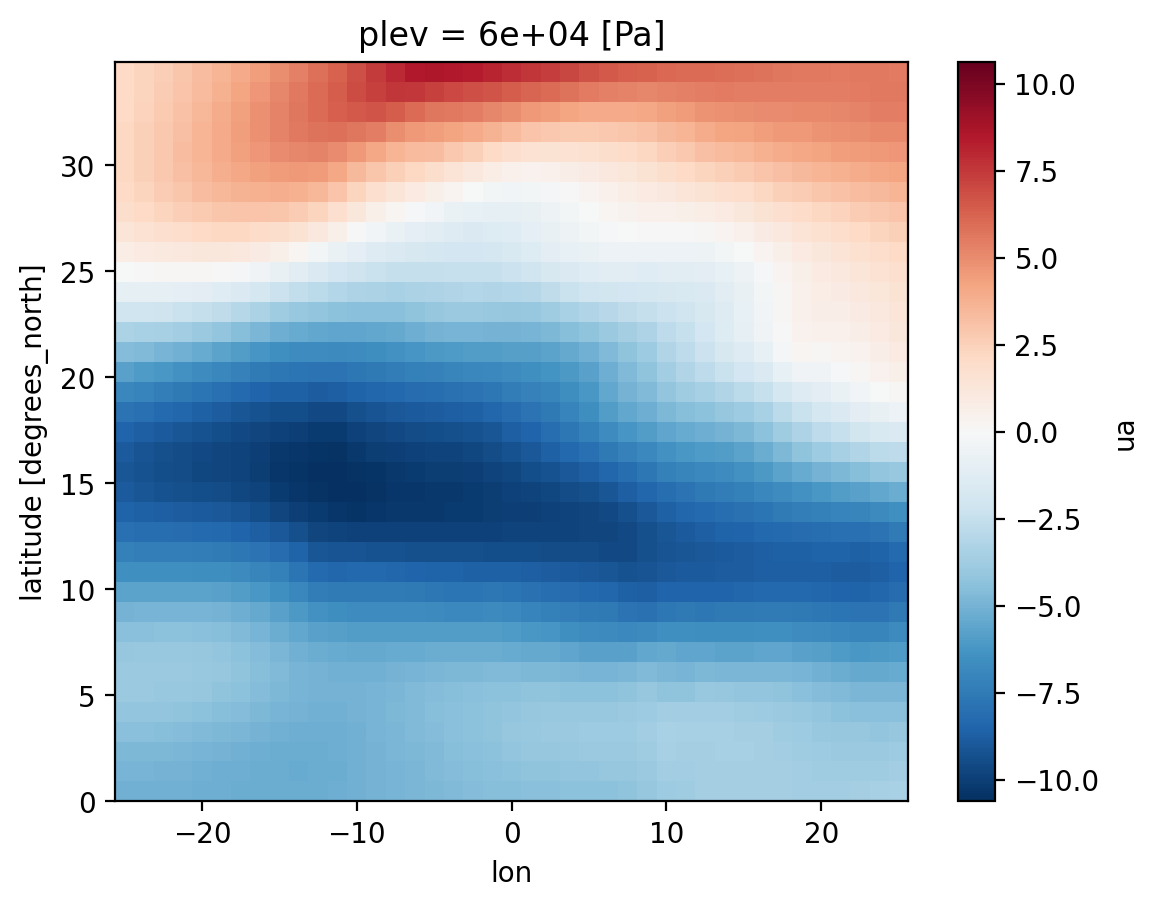

In [103]:
waccm_hist_pt.plot()

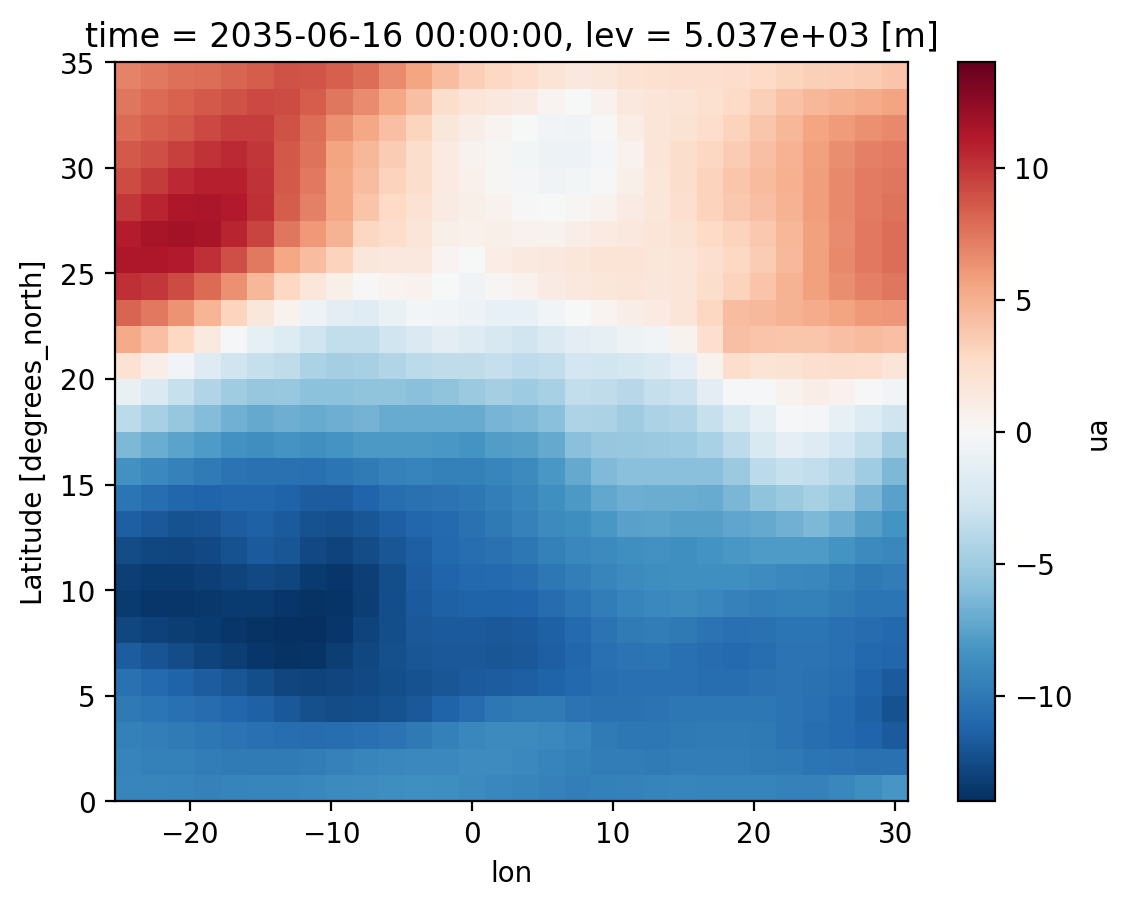

In [48]:
(ukesm_ua).sel(lev=5000,method='nearest')['ua'][0].plot()#.lev/10).values

In [46]:
waccm_U

<xarray.Dataset> Size: 93MB
Dimensions:  (time: 200, lev: 70, lat: 37, lon: 45)
Coordinates:
  * lat      (lat) float64 296B 0.4712 1.414 2.356 3.298 ... 32.51 33.46 34.4
  * lev      (lev) float64 560B 5.96e-06 9.827e-06 1.62e-05 ... 976.3 992.6
  * time     (time) object 2kB 2035-06-01 00:00:00 ... 2084-09-01 00:00:00
  * lon      (lon) float64 360B -25.0 -23.75 -22.5 -21.25 ... 27.5 28.75 30.0
Data variables:
    U        (time, lev, lat, lon) float32 93MB -3.494 -4.242 ... 6.014 5.233

In [100]:
urls = ['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.V.203501-203912.nc']#, 
# urls = ['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.V.204001-208412.nc']

ds = [xr.open_mfdataset(
        [url],
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": False},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )[[var]] for url in urls]

In [88]:
zstore

'r3'

In [ ]:
b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0

## AEJ PROGRESSION

In [63]:
df.query(
    f"activity_id=='CMIP' & \
    experiment_id=='historical' & table_id=='AERmon'")['source_id'].unique()

array(['GFDL-CM4', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'GISS-E2-1-G',
       'CNRM-CM6-1', 'CNRM-ESM2-1', 'CESM2-WACCM', 'CESM2', 'GISS-E2-1-H',
       'UKESM1-0-LL', 'CanESM5', 'CanESM5-CanOE', 'INM-CM4-8',
       'INM-CM5-0', 'HadGEM3-GC31-LL', 'MPI-ESM-1-2-HAM', 'MPI-ESM1-2-LR',
       'MPI-ESM1-2-HR', 'E3SM-1-0', 'NorESM2-LM', 'GISS-E2-1-G-CC',
       'MIROC-ES2L', 'KACE-1-0-G', 'BCC-ESM1', 'CNRM-CM6-1-HR',
       'NorESM2-MM', 'CESM2-WACCM-FV2', 'CESM2-FV2', 'HadGEM3-GC31-MM',
       'E3SM-1-1', 'E3SM-1-1-ECA', 'MRI-ESM2-0', 'EC-Earth3-AerChem',
       'TaiESM1'], dtype=object)

In [60]:
df.query(
    f"activity_id=='CMIP'& source_id=='CESM2-WACCM' & \
    experiment_id=='historical'")['table_id'].unique()

array(['Eyr', 'EmonZ', 'SImon', 'Lmon', 'Ofx', 'IfxGre', 'Omon', 'AERmon',
       'LImon', 'Amon', 'day', 'fx', 'AERmonZ', 'EdayZ', 'Efx', 'Emon',
       'CFday', 'CFmon', 'Eday', 'Oyr', 'Oday'], dtype=object)

In [64]:
lon_name = 'lon'
lat_name = 'lat'

_vars = ['ua']

for var in tqdm(_vars, desc='Loading variables'):
    df_subset = df.query(
    f"activity_id=='CMIP'& source_id=='CESM2-WACCM' & \
    experiment_id=='historical' & table_id=='Amon' & \
    variable_id=='{var}'")

    # get the path to a specific zarr store
    zstores = df_subset.zstore.values
    zstores.sort()
    dds = []
    for zstore in zstores:
        
        _out = xr.open_dataset(
            zstore,
            engine="zarr",
            # consolidated=True,
            chunks={},                        # or {} / None or 'auto' as you prefer
            storage_options={"anon": True,
                            "asynchronous": False}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
            "time" : time_slice,
            lon_name : lon_slice, 
            lat_name : lat_slice})
        dds.append(_out.mean('nbnd'))
        
    DS = xr.concat(dds, dim='ensemble').mean('ensemble')
    locals()[f'waccm_hist_{var}'] =DS.load()

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/storage/_fsspec.py:182: UserWarning: fs (<s3fs.core.S3FileSystem object at 0x7fa53c6990a0>) was not created with `asynchronous=True`, this may lead to surprising behavior
  return cls(fs=fs, path=path, read_only=read_only, allowed_exceptions=allowed_exceptions)
/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/storage/_fsspec.py:182: UserWarning: fs (<s3fs.core.S3FileSystem object at 0x7fa53c6990a0>) was not created with `asynchronous=True`, this may lead to surprising behavior
  return cls(fs=fs, path=path, read_only=read_only, allowed_exceptions=allowed_exceptions)
/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/storage/_fsspec.py:182: UserWarning: fs (<s3fs.core.S3FileSystem object at 0x7fa53c6990a0>) was not created with `asynchronous=True`, this may lead to surprising behavior
  return cls(fs=fs, path=path, read_only=read_only, allowed_exceptions=allowed_exceptions)
Loading variables: 100%|██████████| 1

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/storage/_fsspec.py:245: ZarrUserWarning: fs (<s3fs.core.S3FileSystem object at 0x7f0f2fdc0410>) was not created with `asynchronous=True`, this may lead to surprising behavior
  return cls(fs=fs, path=path, read_only=read_only, allowed_exceptions=allowed_exceptions)


/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/storage/_fsspec.py:245: ZarrUserWarning: fs (<s3fs.core.S3FileSystem object at 0x7f0f2fdc0410>) was not created with `asynchronous=True`, this may lead to surprising behavior
  return cls(fs=fs, path=path, read_only=read_only, allowed_exceptions=allowed_exceptions)


/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/storage/_fsspec.py:245: ZarrUserWarning: fs (<s3fs.core.S3FileSystem object at 0x7f0f2fdc0410>) was not created with `asynchronous=True`, this may lead to surprising behavior
  return cls(fs=fs, path=path, read_only=read_only, allowed_exceptions=allowed_exceptions)


Loading variables: 100%|██████████| 1/1 [00:26<00:00, 26.13s/it]

Loading variables: 100%|██████████| 1/1 [00:26<00:00, 26.13s/it]

In [11]:
lon_name = 'lon'
lat_name = 'lat'

_vars = ['ua']#,'va','psl','ts','zg']

for var in tqdm(_vars, desc='Loading variables'):
    df_subset = df.query(
    f"activity_id=='CMIP'& source_id=='UKESM1-0-LL' & \
    experiment_id=='historical' & table_id=='Amon' & \
    variable_id=='{var}'")

    # get the path to a specific zarr store
    zstores = df_subset.zstore.values
    zstores.sort()
    dds = []
    for zstore in zstores:
        
        _out = xr.open_dataset(
            zstore,
            engine="zarr",
            # consolidated=True,
            chunks={},                        # or {} / None or 'auto' as you prefer
            storage_options={"anon": True}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
            "time" : time_slice,
            lon_name : lon_slice, 
            lat_name : lat_slice})
        dds.append(_out.mean('bnds'))
        
    DS = xr.concat(dds, dim='ensemble').mean('ensemble')
    locals()[f'ukesm_hist_{var}'] =DS.load()

Loading variables: 100%|██████████| 1/1 [01:07<00:00, 67.38s/it]


Loading variables: 100%|██████████| 1/1 [01:24<00:00, 84.53s/it]

Loading variables: 100%|██████████| 1/1 [01:24<00:00, 84.53s/it]

In [26]:
ukesm_hist_ua

<xarray.Dataset> Size: 24MB
Dimensions:  (time: 408, plev: 19, lat: 29, lon: 27)
Coordinates:
  * time     (time) object 3kB 1981-01-16 00:00:00 ... 2014-12-16 00:00:00
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat      (lat) float64 232B 0.0 1.25 2.5 3.75 5.0 ... 31.25 32.5 33.75 35.0
  * lon      (lon) float64 216B -24.38 -22.5 -20.62 -18.75 ... 20.62 22.5 24.38
Data variables:
    ua       (time, plev, lat, lon) float32 24MB -2.956 -2.698 ... 50.53 49.8
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  176400.0
    cmor_version:           3.4.0
    ...                     ...
    table_info:             Creation Date:(13 December 2018) MD5:f0588f7f55b5...
    title:                  UKESM1-0-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/dc571869-e06e-4c0c-9695-ab4ff1187dc8...
    variable_id:            ua
    variable_name:          ua
    variant_label:          r10i1p1f2

np.unique(df.query(
    f"activity_id=='CMIP'& source_id=='UKESM1-0-LL' & \
    experiment_id=='historical' & table_id=='Amon'")['variable_id'].values)

In [12]:
sim_time = slice("2035","2085")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

In [13]:
_vars = ['ua']#,'va']
zstores = ['r12i1p1f2','r2i1p1f2','r3i1p1f2']

for var in _vars:
    dd = []
    for zstore in zstores:    
        _out = open_s3_xarray_ukesm(
            bucket=f"reflective-persistent-prod-large",
            group="UKESM1-1",
            scenario=f"G6-1p5K-HiLLA/{zstore}/ap4/AERmon/{var}",
            variable_name=f"{var}",
            partial_filename=f"AERmon_UKESM1-1-LL_g6-1p5-hilla_{zstore}_gn",
        ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)
        dd.append(_out)

    DS = xr.concat(dd, dim='ensemble').mean('ensemble')
    locals()[f'ukesm_{var}'] = DS.load()
    

reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r12i1p1f2/ap4/AERmon/ua/ua_AERmon_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r2i1p1f2/ap4/AERmon/ua/ua_AERmon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r3i1p1f2/ap4/AERmon/ua/ua_AERmon_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn*.nc
lat


In [14]:
sim_time = slice("2035","2084")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)
_vars = ['U']#,'TS', 'V', 'PSL','Q']
_anons = [False, False, False, False,False]
zstores = ['r1','r2','r3']

for var,an  in tqdm(zip(_vars,_anons)):
    dd = []
    for zstore in zstores:
        print(zstore)
        _out = open_s3_xarray_waccm(
            bucket="reflective-persistent-prod-large",
            group="CESM2-WACCM",
            scenario="G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.",
            variable_name=var,
            partial_filename="",
            anon1=an
        ).sel( lon=_lon_slice, lat=_lat_slice)[[var]]
        
        dd.append(_out)
    DS = xr.concat(dd, dim='ensemble').mean('ensemble')
    locals()[f'waccm_{var}'] = DS.load()

# waccm_e2 = open_s3_xarray_waccm(
#     bucket="reflective-persistent-prod-large",
#     group="CESM2-WACCM",
#     scenario="G6-1.5k-HiLLA/r2/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h1.",
#     variable_name="PRECT",
#     partial_filename="",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# waccm_e3 = open_s3_xarray_waccm(
#     bucket="reflective-persistent-prod-large",
#     group="CESM2-WACCM",
#     scenario="G6-1.5k-HiLLA/r3/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h1.",
#     variable_name="PRECT",
#     partial_filename="",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# ukesm_e1 = open_s3_xarray(
#     bucket="reflective-persistent-prod-large",
#     group="UKESM1-1",
#     scenario="G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr",
#     variable_name="pr",
#     partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

0it [00:00, ?it/s]

r1
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U*.nc
lat
r2
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U*.nc
lat
r3
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6

1it [03:17, 197.28s/it]


r2
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U*.nc


lat
r3
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.U*.nc


lat


1it [00:54, 54.53s/it]

1it [00:54, 54.53s/it]

/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/srv/conda/envs/not

UKESM1$_{HIST}$
WACCM6$_{HIST}$
WACCM6$_{HIST}$ − UKESM1$_{HIST}$
UKESM1$_{SAI}$
WACCM6$_{SAI}$
WACCM6$_{SAI}$ − UKESM1$_{SAI}$


/tmp/ipykernel_100/3227018561.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=2)


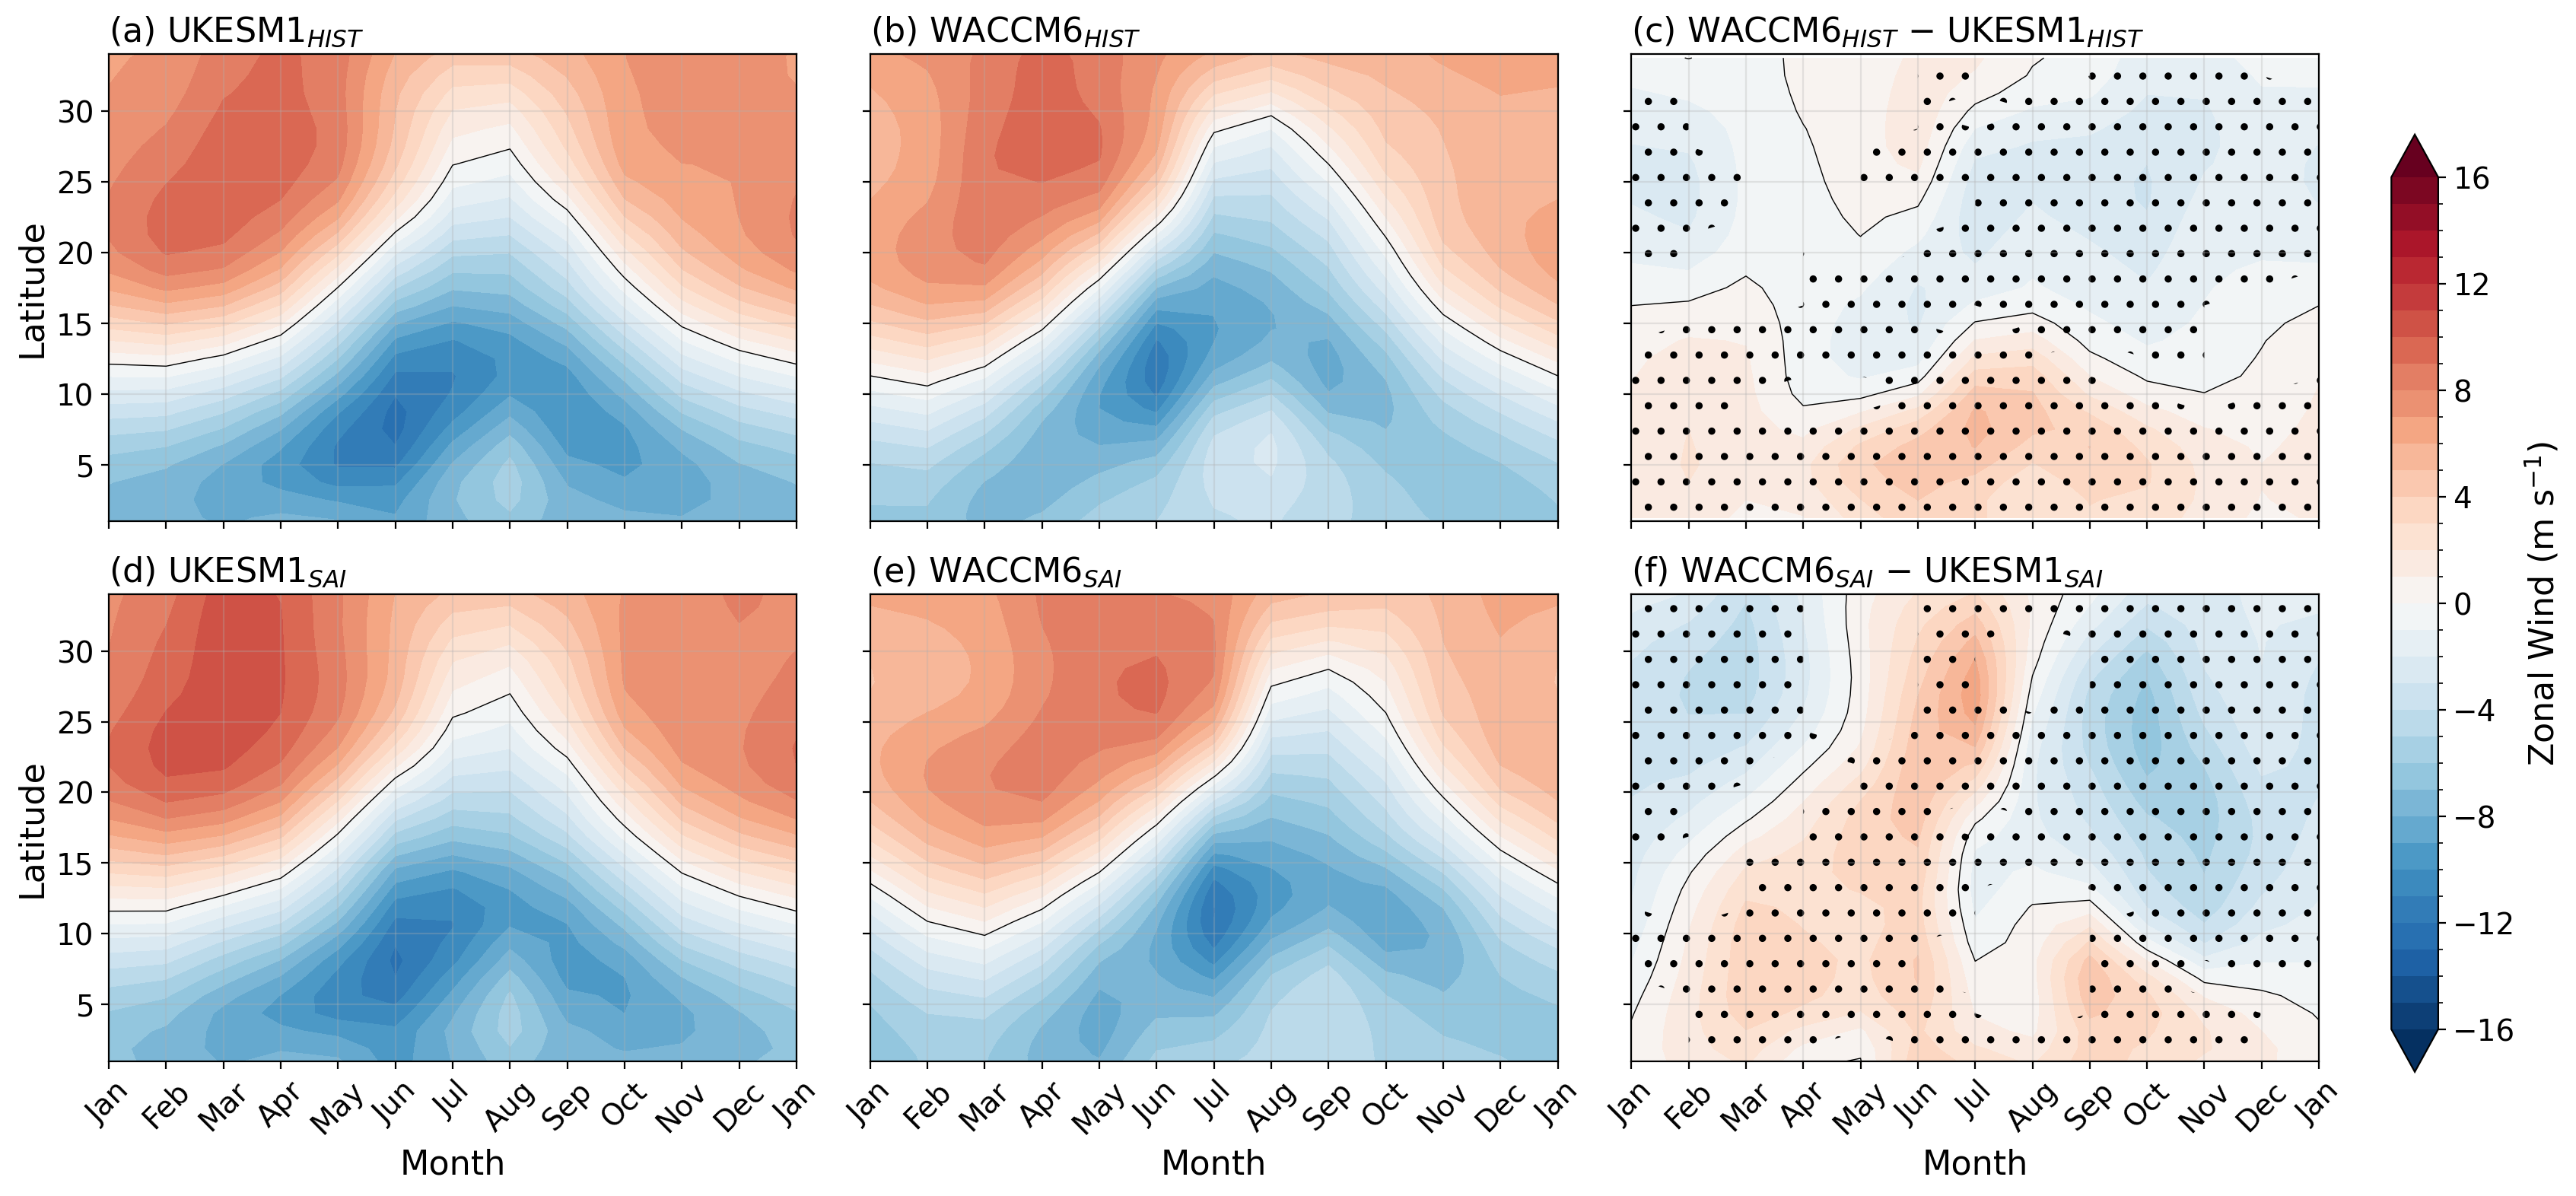

/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/srv/conda/envs/not

/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.stats import ttest_ind

def height_to_pressure(z):
    p0 = 101325.0
    T0 = 288.15
    g = 9.80665
    L = 0.0065
    R = 287.05
    return p0 * (1 - L*z/T0)**(g/(R*L))
    
# =========================================
# Months
# =========================================
months = list(range(1, 13))

# =========================================
# Zonal mean
# =========================================
ukesm_u = ukesm_ua.mean("lon")
waccm_u = waccm_U.mean("lon")
ukesm_hist_u = ukesm_hist_ua.mean("lon")
waccm_hist_u = waccm_hist_ua.mean("lon")

# =========================================
# Select months and pressure levels
# =========================================
ukesm_u_all = ukesm_u.sel(time=ukesm_u.time.dt.month.isin(months))["ua"].sel(lev=4250, method="nearest")
waccm_u_all = waccm_u.sel(time=waccm_u.time.dt.month.isin(months))["U"].sel(lev=600, method="nearest")
ukesm_hist_all = ukesm_hist_u.sel(time=ukesm_hist_u.time.dt.month.isin(months))["ua"].sel(plev=60000)
waccm_hist_all = waccm_hist_u.sel(time=waccm_hist_u.time.dt.month.isin(months))["ua"].sel(plev=60000)

# =========================================
# Monthly climatologies
# =========================================
ukesm_u_monthly = ukesm_u_all.groupby("time.month").mean("time")
waccm_u_monthly = waccm_u_all.groupby("time.month").mean("time")
ukesm_hist_monthly = ukesm_hist_all.groupby("time.month").mean("time")
waccm_hist_monthly = waccm_hist_all.groupby("time.month").mean("time")

# =========================================
# Interpolate WACCM → UKESM latitude grid
# =========================================
waccm_u_monthly_i = waccm_u_monthly.interp(lat=ukesm_u_monthly.lat)
waccm_hist_monthly_i = waccm_hist_monthly.interp(lat=ukesm_hist_monthly.lat)
waccm_u_all_i = waccm_u_all.interp(lat=ukesm_u_all.lat)
waccm_hist_all_i = waccm_hist_all.interp(lat=ukesm_hist_all.lat)

# =========================================
# Original coordinate conversion
# =========================================
ukesm_u_monthly["lev"] = height_to_pressure(ukesm_u_monthly["lev"]) / 100

# =========================================
# Student's t-test
# =========================================
def monthly_ttest(waccm, ukesm):
    pvals = []
    for month in months:
        w = waccm.sel(time=waccm.time.dt.month == month)
        u = ukesm.sel(time=ukesm.time.dt.month == month)
        _, p = ttest_ind(w.values, u.values, axis=0, equal_var=True, nan_policy="omit")
        pvals.append(p)
    return xr.DataArray(np.array(pvals), dims=["month", "lat"], coords={"month": months, "lat": ukesm.lat})


    
p_hist = monthly_ttest(waccm_hist_all_i, ukesm_hist_all)
p_sai = monthly_ttest(waccm_u_all_i, ukesm_u_all)

# =========================================
# Wrap December → January
# =========================================
def wrap_january(da):
    jan = da.isel(month=0).expand_dims(month=[13])
    return xr.concat([da, jan], dim="month")
    
ukesm_u_monthly = wrap_january(ukesm_u_monthly)
waccm_u_monthly = wrap_january(waccm_u_monthly)
waccm_u_monthly_i = wrap_january(waccm_u_monthly_i)
ukesm_hist_monthly = wrap_january(ukesm_hist_monthly)
waccm_hist_monthly = wrap_january(waccm_hist_monthly)
waccm_hist_monthly_i = wrap_january(waccm_hist_monthly_i)
p_hist = wrap_january(p_hist)
p_sai = wrap_january(p_sai)

# =========================================
# Differences
# =========================================
diff_sai = waccm_u_monthly_i - ukesm_u_monthly
diff_hist = waccm_hist_monthly_i - ukesm_hist_monthly

# =========================================
# Plotting fields
# =========================================
fields = [[ukesm_hist_monthly, waccm_hist_monthly, diff_hist],
          [ukesm_u_monthly, waccm_u_monthly, diff_sai]]

titles = [["UKESM1$_{HIST}$", "WACCM6$_{HIST}$", "WACCM6$_{HIST}$ − UKESM1$_{HIST}$"],
          ["UKESM1$_{SAI}$", "WACCM6$_{SAI}$", "WACCM6$_{SAI}$ − UKESM1$_{SAI}$"]]

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan"]

# =========================================
# Plot
# =========================================
vmin, vmax = -16, 16
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)

for i in range(2):
    for j in range(3):
        print(titles[i][j])
        ax = axes[i, j]
        field = fields[i][j].T

        im = field.plot.contourf(ax=ax, cmap="RdBu_r", vmin=vmin, vmax=vmax,
                                 levels=np.arange(vmin, vmax + 1, 1), add_colorbar=False, extend="both")

        field.plot.contour(ax=ax, levels=[0], colors="black", linewidths=0.5, add_colorbar=False)

        # Statistical significance only in difference panels
        if j == 2:
            pval = p_hist if i == 0 else p_sai
            sig = xr.where(pval < 0.05, 1, np.nan)
            sig.T.plot.contourf(ax=ax, levels=[0.5, 1.5], colors="none", hatches=["."], add_colorbar=False)

        ax.set_xlabel("Month" if i == 1 else "", fontsize=16)
        ax.set_ylabel("Latitude" if j == 0 else "", fontsize=16)
        ax.set_title(f"({chr(97 + i*3 + j)}) {titles[i][j]}", loc="left", fontsize=16)
        ax.set_title('')
        ax.set_ylim(1, 34)
        ax.set_xlim(1, 13)
        ax.set_xticks(np.arange(1, 14))
        ax.set_xticklabels(month_names, fontsize=14, rotation=45)
        ax.tick_params(axis="both", labelsize=14)
        ax.grid(alpha=0.3)

# =========================================
# Shared colorbar
# =========================================
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation="vertical", fraction=0.03, pad=-0.2)
cbar.set_label("Zonal Wind (m s$^{-1}$)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# =========================================
# Save
# =========================================
plt.tight_layout(w_pad=2)
# plt.savefig("Images/AEJ_lat_month_cross_section_600hPa.png", dpi=250, bbox_inches="tight")
plt.show()

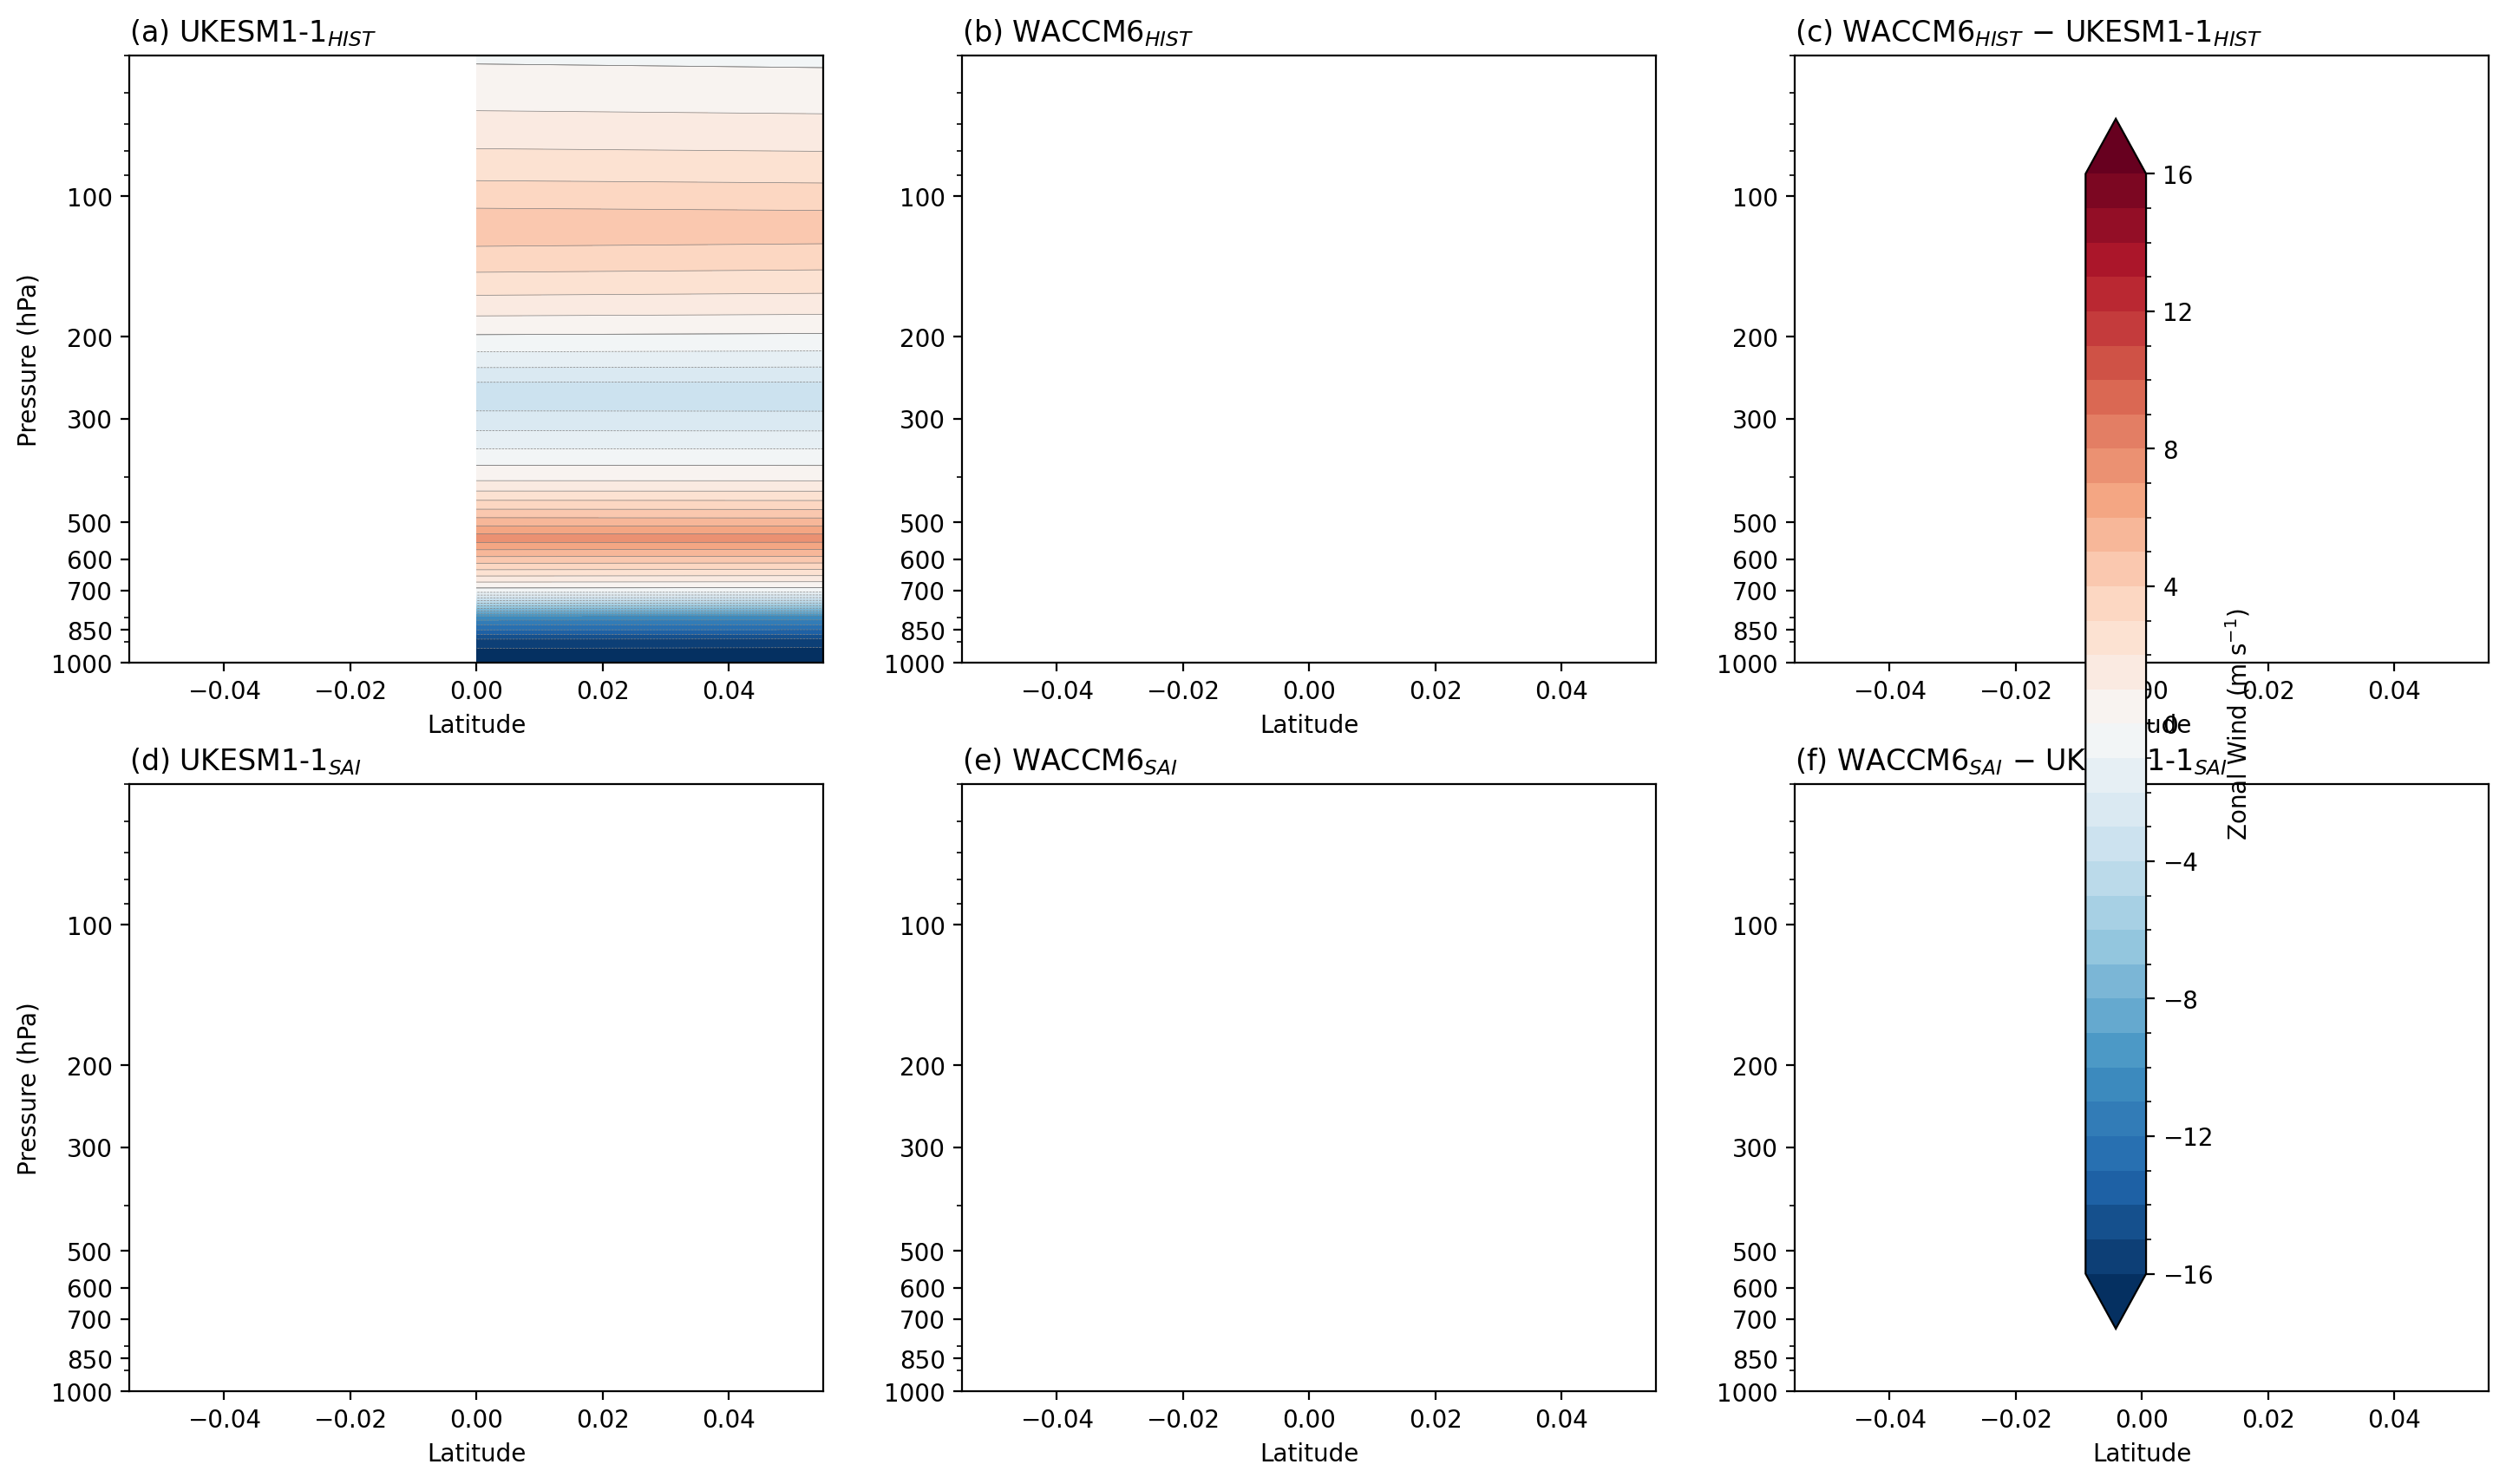

In [71]:
months = [6, 7, 8, 9]

# =========================================
# Zonal mean
# =========================================
ukesm_u = ukesm_ua.mean("lon")
waccm_u = waccm_U.mean("lon")

ukesm_hist_u = ukesm_hist_ua.mean("lon")
waccm_hist_u = waccm_hist_ua.mean("lon")  # make sure you have waccm_hist_U

# =========================================
# JJAS mean
# =========================================
ukesm_u_jjas = ukesm_u.sel(time=ukesm_u.time.dt.month.isin(months)).mean("time")['ua']
waccm_u_jjas = waccm_u.sel(time=waccm_u.time.dt.month.isin(months)).mean("time")['U']

ukesm_hist_jjas = ukesm_hist_u.sel(time=ukesm_hist_u.time.dt.month.isin(months)).mean("time")['ua']
waccm_hist_jjas = waccm_hist_u.sel(time=waccm_hist_u.time.dt.month.isin(months)).mean("time")['ua']

# =========================================
# Convert hybrid height to pressure for UKESM
# =========================================
ukesm_u_jjas['lev'] = height_to_pressure(ukesm_u_jjas['lev']) / 100
ukesm_hist_jjas['lev'] = height_to_pressure(ukesm_hist_jjas['plev']) / 100

# =========================================
# Interpolate WACCM → UKESM grid
# =========================================
waccm_u_jjas_i = waccm_u_jjas.interp(lat=ukesm_u_jjas.lat, lev=ukesm_u_jjas.lev)
waccm_hist_jjas_i = waccm_hist_jjas.interp(lat=ukesm_hist_jjas.lat, plev=ukesm_hist_jjas.lev)

# =========================================
# Differences
# =========================================
u_diff = waccm_u_jjas_i - ukesm_u_jjas
hist_diff = waccm_hist_jjas_i - ukesm_hist_jjas

# =========================================
# Plotting 2 rows × 3 cols
# =========================================
import numpy as np
import matplotlib.pyplot as plt

fields = [
    [ukesm_hist_jjas, waccm_hist_jjas_i, hist_diff],
    [ukesm_u_jjas, waccm_u_jjas_i, u_diff]
]

titles = [
    ["UKESM1-1$_{HIST}$", "WACCM6$_{HIST}$", "WACCM6$_{HIST}$ − UKESM1-1$_{HIST}$"],
    ["UKESM1-1$_{SAI}$", "WACCM6$_{SAI}$", "WACCM6$_{SAI}$ − UKESM1-1$_{SAI}$"]
]

vmin, vmax = -16, 16
fig, axes = plt.subplots(2, 3, figsize=(15,10))  # two rows now

for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        field = fields[i][j]
        im = field.plot.contourf(
            ax=ax,
            x='lat',
            y='lev',
            cmap='RdBu_r',
            levels=np.arange(vmin, vmax+1, 1),
            add_colorbar=False,
            extend='both'
        )
        field.plot.contour(
            ax=ax,
            x='lat',
            y='lev',
            colors='grey',
            levels=np.arange(vmin, vmax+1, 1),
            linewidths=0.25,
            add_colorbar=False,
            extend='both'
        )
        # Zero contour
        field.plot.contour(
            ax=ax,
            x='lat',
            y='lev',
            levels=[0],
            colors='grey',
            linewidths=0.25
        )
        # Axis formatting
        ax.invert_yaxis()
        ax.set_yscale('log')
        ax.set_yticks([1000, 850, 700, 600, 500, 300, 200, 100])
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
        ax.set_ylim(1000, 50)
        ax.set_xlabel("Latitude")
        if j == 0:
            ax.set_ylabel("Pressure (hPa)")
        else:
            ax.set_ylabel('')
        ax.set_title(f"({chr(97 + i*3 + j)}) {titles[i][j]}", loc='left')

# =========================================
# Shared colorbar
# =========================================
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    orientation='vertical',
    fraction=0.03,
    pad=-0.2
)
cbar.set_label("Zonal Wind (m s$^{-1}$)")

# plt.tight_layout()
# plt.savefig('Images/AEJ_zonal_winds_cross_section_HIST_SAI.png', dpi=250)
plt.show()

/tmp/ipykernel_100/3476395378.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


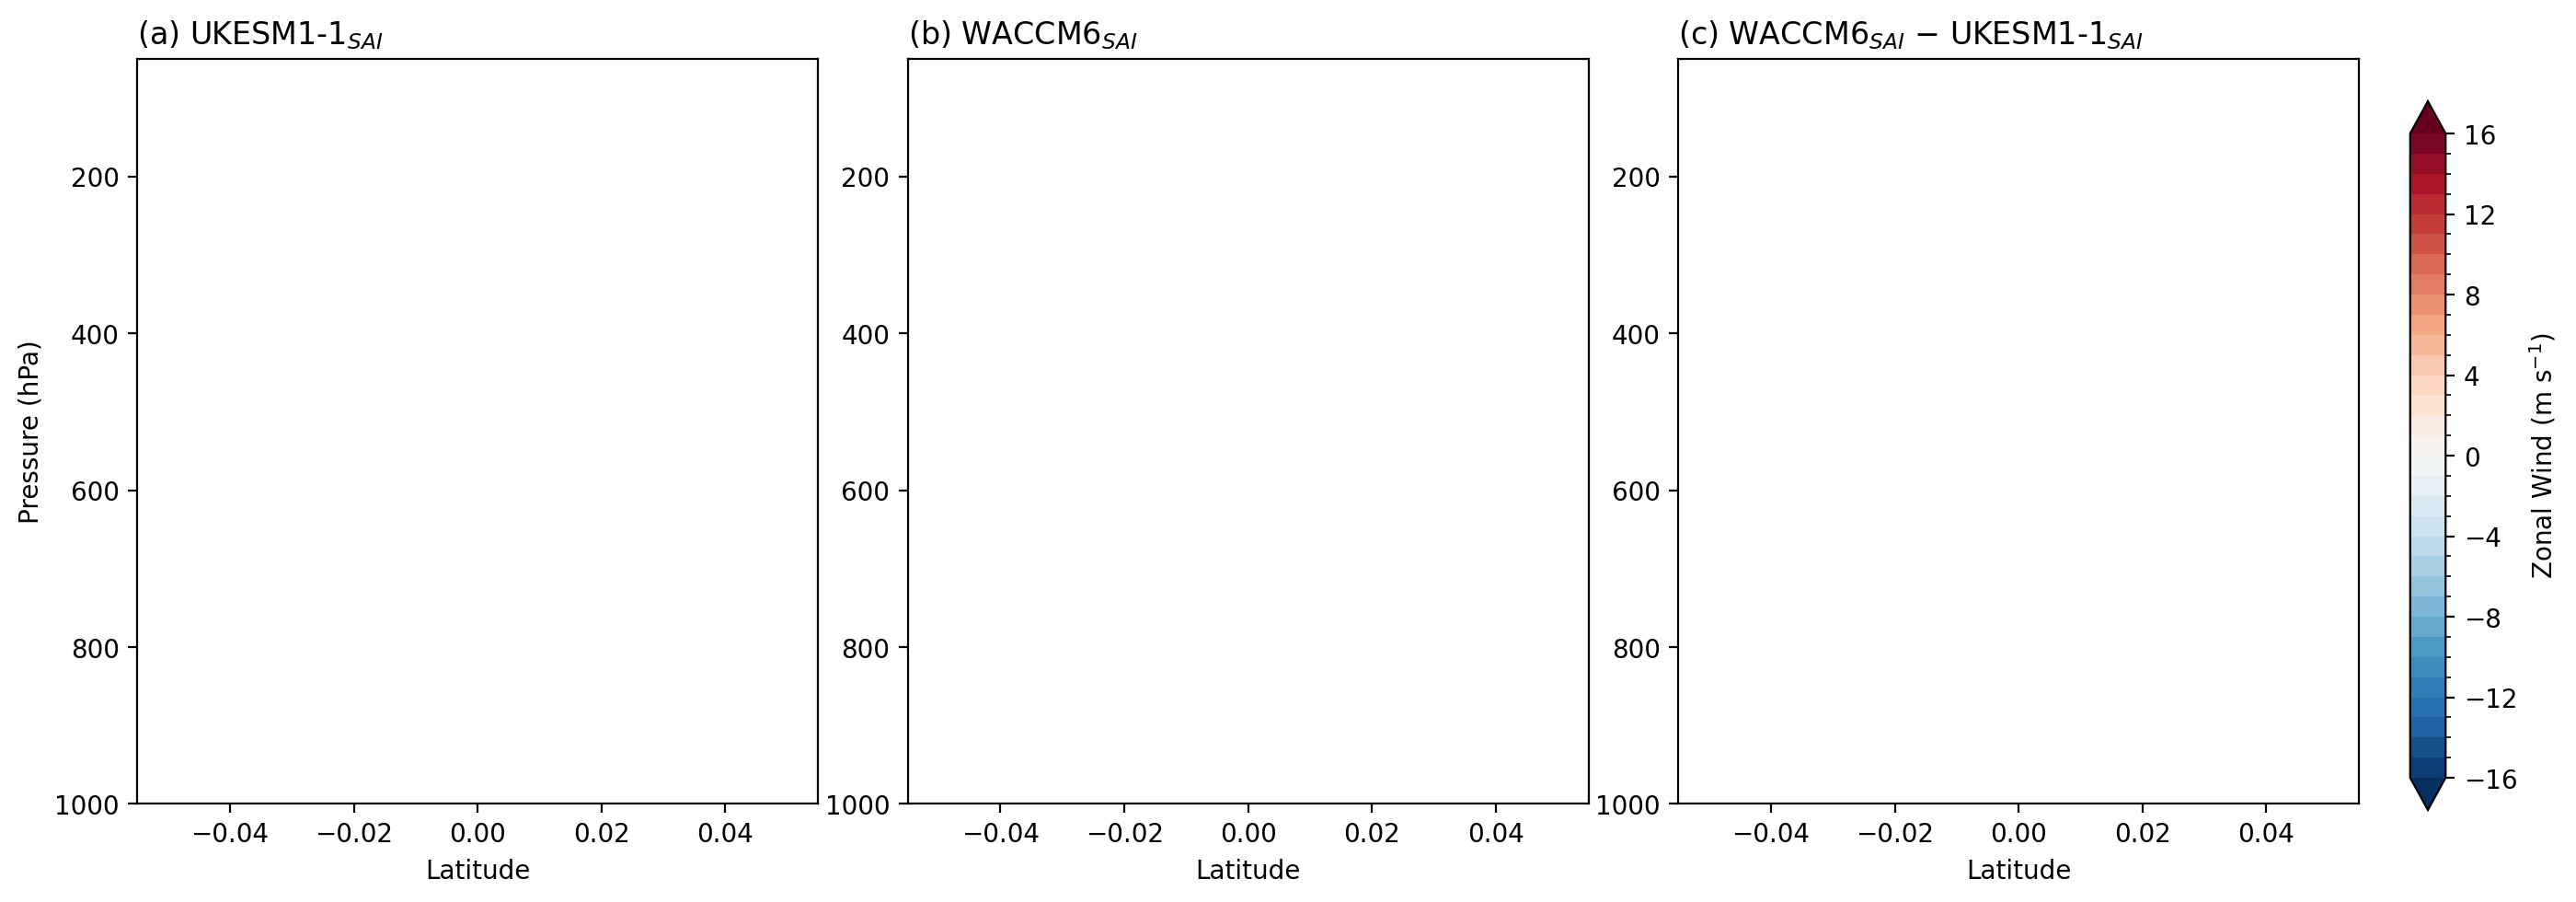

In [74]:
months = [6, 7, 8, 9]

# =========================================
# Zonal mean
# =========================================
ukesm_u = ukesm_ua.mean("lon")
waccm_u = waccm_U.mean("lon")

# =========================================
# JJAS mean
# =========================================
ukesm_u_jjas = ukesm_u.sel(time=ukesm_u.time.dt.month.isin(months)).mean("time")['ua']
waccm_u_jjas = waccm_u.sel(time=waccm_u.time.dt.month.isin(months)).mean("time")['U']

ukesm_u_jjas['lev']=height_to_pressure(ukesm_u_jjas['lev'])/100
# =========================================
# Convert pressure to hPa (ONLY if needed)
# =========================================
# if ukesm_u_jjas.lev.max() > 2000:
#     ukesm_u_jjas = ukesm_u_jjas.assign_coords(lev=ukesm_u_jjas.lev / 100)

# if waccm_u_jjas.lev.max() > 2000:
#     waccm_u_jjas = waccm_u_jjas.assign_coords(lev=waccm_u_jjas.lev / 100)

# =========================================
# Interpolate WACCM → UKESM grid
# =========================================
waccm_u_jjas_i = waccm_u_jjas.interp(
    lat=ukesm_u_jjas.lat,
    lev=ukesm_u_jjas.lev
)

# =========================================
# Difference
# =========================================
u_diff = waccm_u_jjas_i - ukesm_u_jjas


# =========================================
# Latitude–Pressure Cross-Section (Zonal Mean)
# Using xarray plotting with shared colorbar
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# Already computed:
# ukesm_u_jjas, waccm_u_jjas_i, u_diff
# Dimensions: lev (pressure in hPa), lat

fields = [
    (ukesm_u_jjas, "UKESM1-1$_{SAI}$"),
    (waccm_u_jjas_i, "WACCM6$_{SAI}$"),
    (u_diff, "WACCM6$_{SAI}$ − UKESM1-1$_{SAI}$")
]

vmin, vmax = -16, 16  # same scale for all
fig, axes = plt.subplots(1, 3, figsize=(15,5))#, sharey=True)

for i, (ax, (field, title)) in enumerate(zip(axes, fields)):
    im = field.plot.contourf(
        ax=ax,
        x='lat',
        y='lev',
        cmap='RdBu_r',
        levels=np.arange(vmin, vmax+1, 1),
        add_colorbar=False,
        extend='both'
    )
    field.plot.contour(
        ax=ax,
        x='lat',
        y='lev',
        colors='grey',
        levels=np.arange(vmin, vmax+1, 1),
        linewidths=0.25,
        add_colorbar=False,
        extend='both'
    )

    # Zero contour
    field.plot.contour(
        ax=ax,
        x='lat',
        y='lev',
        levels=[0],
        colors='grey',
        linewidths=0.25
    )

    # Axis formatting
    # ax.invert_yaxis()
    # ax.set_yscale('log')
    # ax.set_yticks([1000, 850, 700, 600, 500, 300, 200, 100])
    # ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_ylim(1000, 50)

    ax.set_xlabel("Latitude")
    
    ax.set_ylabel("Pressure (hPa)") if i == 0 else ax.set_ylabel('')
    ax.set_title(f"({chr(97+i)}) {title}", loc='left')

# =========================================
# Shared colorbar
# =========================================
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    orientation='vertical',
    fraction=0.03,
    pad=-0.2
)
cbar.set_label("Zonal Wind (m s$^{-1}$)")

plt.tight_layout()
# plt.savefig('Images/AEJ_zonal_winds_cross_section.png',dpi=250)
plt.show()
# do not change anything. Just add a first row for Historical data for both ukesm and waccm and their difference.

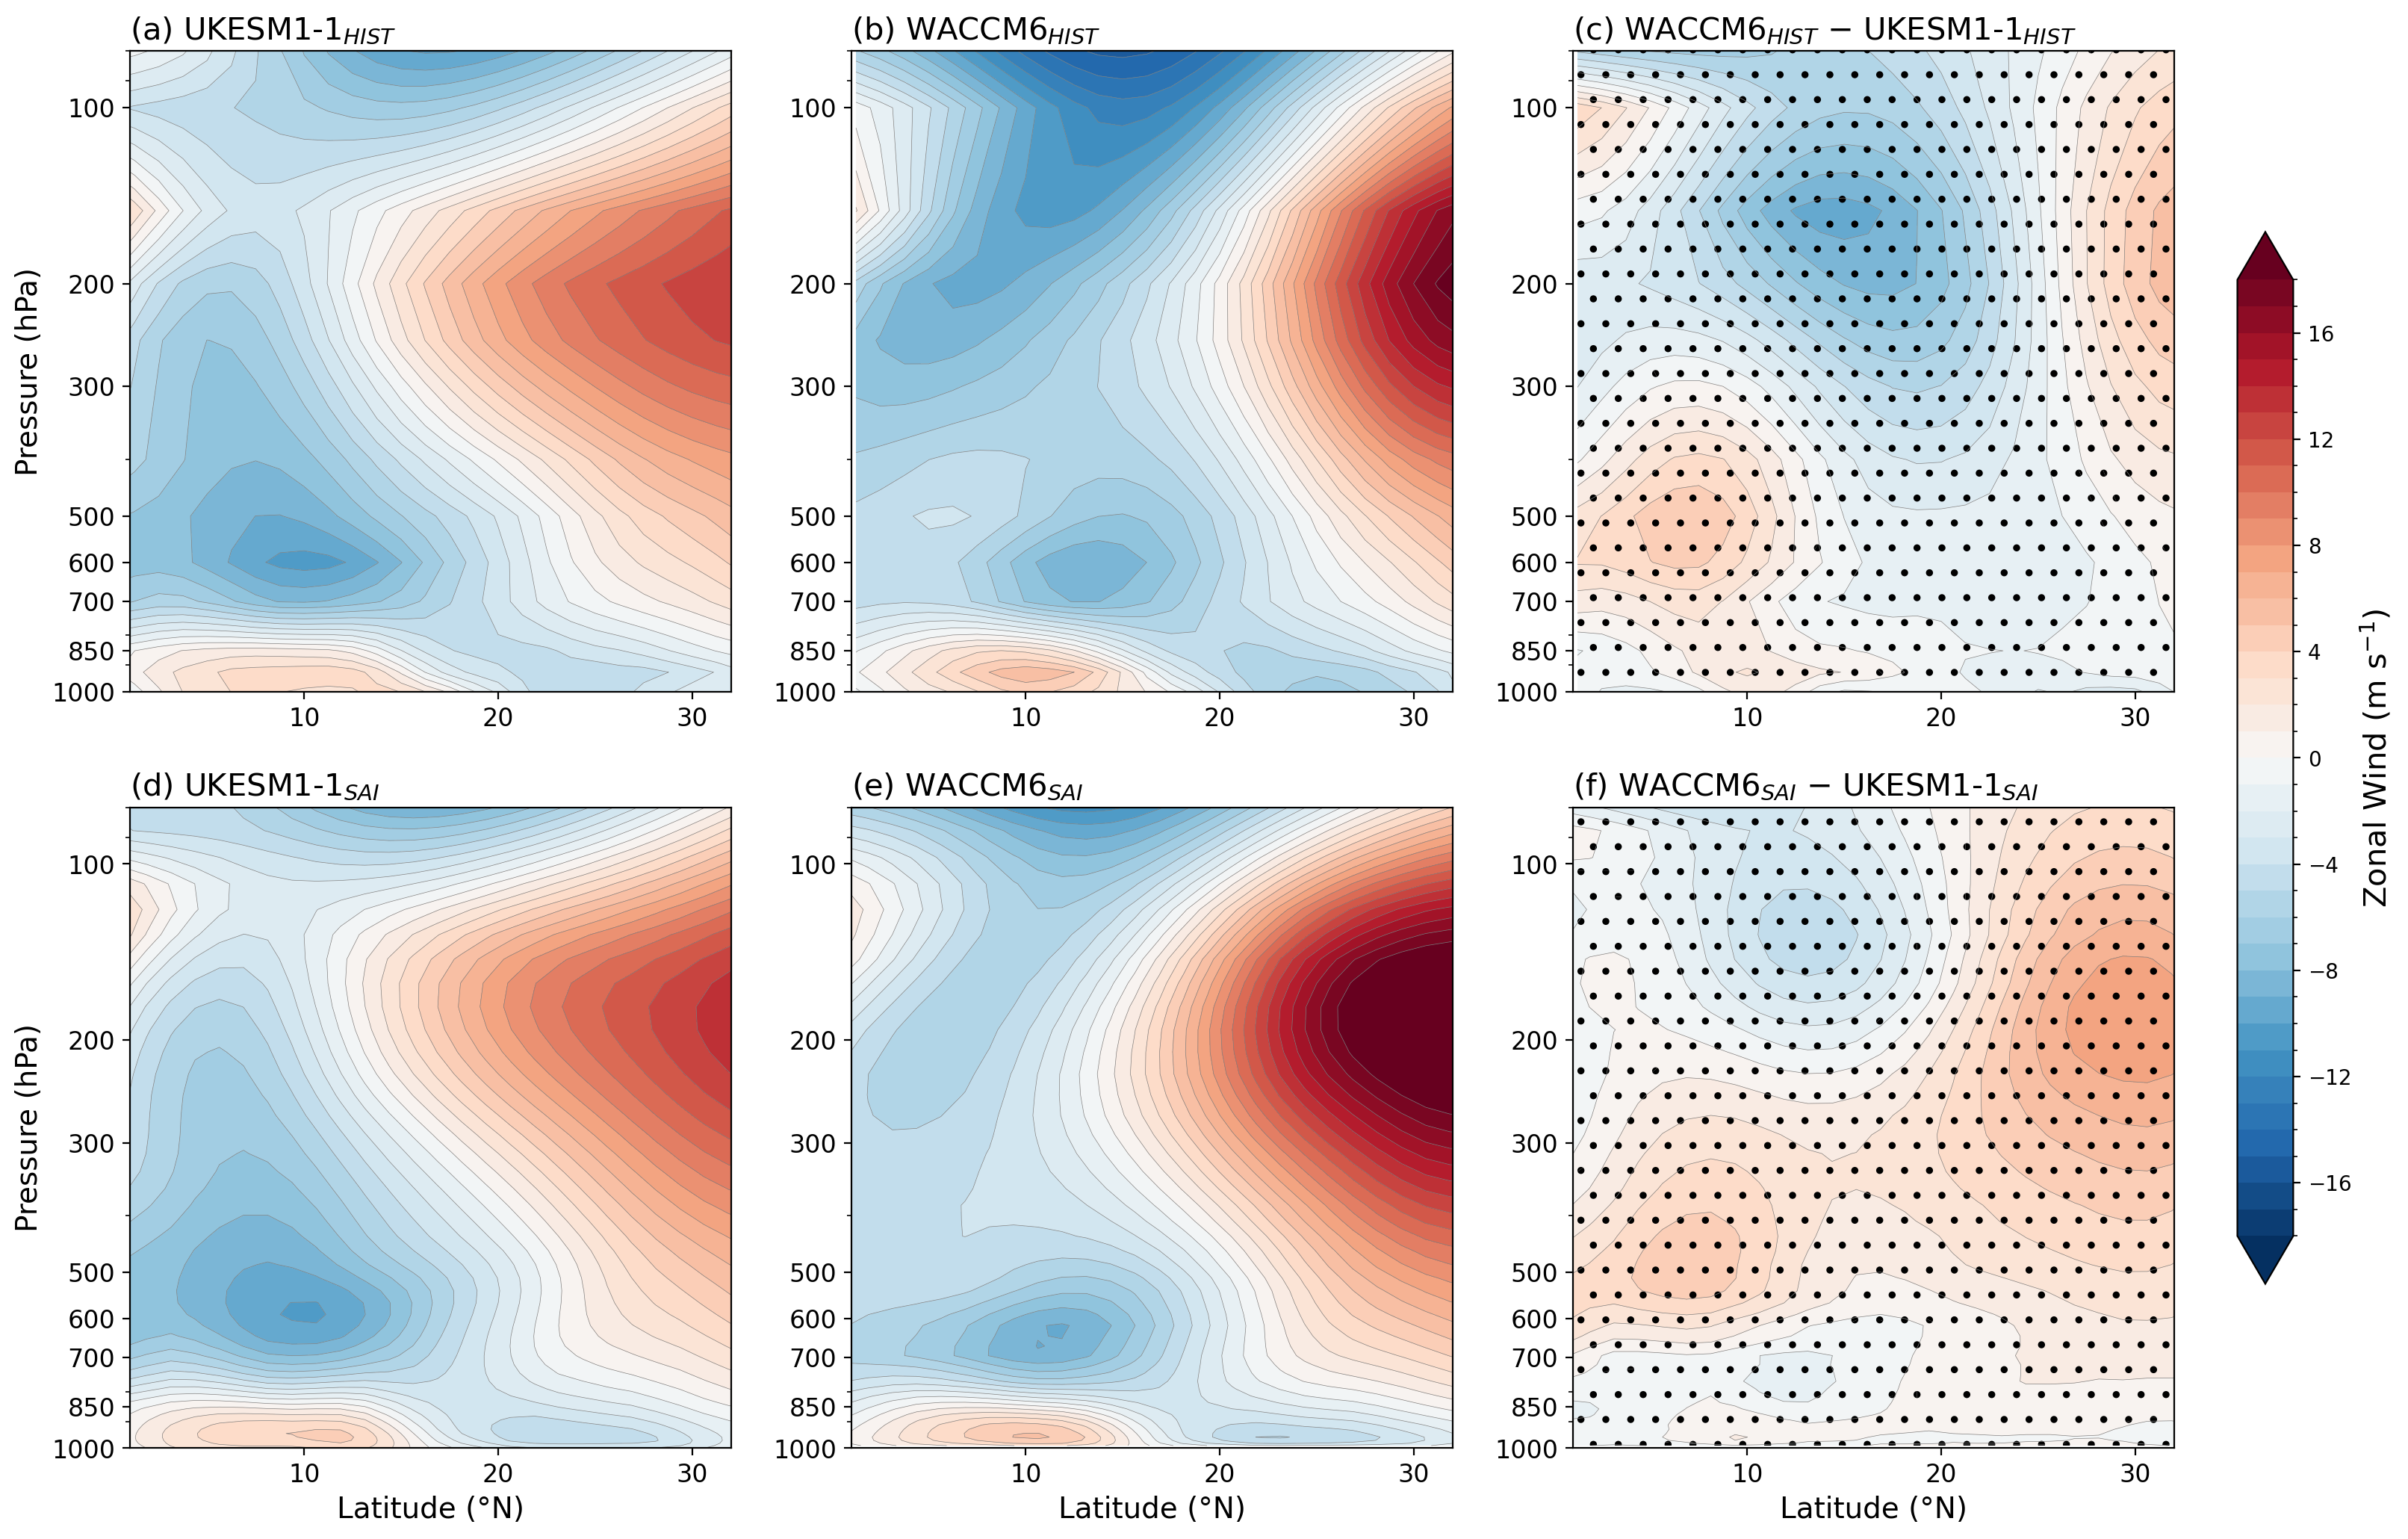

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullFormatter
from pathlib import Path

months = [6, 7, 8, 9]

# =========================================
# Approximate height → pressure
# Input: meters; output: Pa
# Valid here for nominal heights 0–20 km
# =========================================
def height_to_pressure(height):
    z = np.asarray(height, dtype=float)

    p = np.full(z.shape, np.nan, dtype=float)

    # Standard-atmosphere troposphere.
    lower = (z >= 0) & (z <= 11000)
    p[lower] = 101325.0 * (
        1 - 0.0065 * z[lower] / 288.15
    ) ** 5.25588

    # Isothermal layer above 11 km.
    upper = (z > 11000) & (z <= 20000)
    p[upper] = 22632.06 * np.exp(
        -9.80665 * (z[upper] - 11000) / (287.05 * 216.65)
    )

    return p


# =========================================
# Zonal mean
# =========================================
ukesm_u = ukesm_ua["ua"].mean("lon")
waccm_u = waccm_U["U"].mean("lon")

ukesm_hist_u = ukesm_hist_ua["ua"].mean("lon").rename({'plev':'lev'})
waccm_hist_u = waccm_hist_ua["ua"].mean("lon").rename({'plev':'lev'})

ukesm_hist_u = ukesm_hist_u.interp({'lev':waccm_hist_u.lev})

# =========================================
# JJAS mean
# =========================================
ukesm_u_jjas = ukesm_u.sel(
    time=ukesm_u.time.dt.month.isin(months)
).mean("time")

waccm_u_jjas = waccm_u.sel(
    time=waccm_u.time.dt.month.isin(months)
).mean("time")

ukesm_hist_jjas = ukesm_hist_u.sel(
    time=ukesm_hist_u.time.dt.month.isin(months)
).mean("time")

waccm_hist_jjas = waccm_hist_u.sel(
    time=waccm_hist_u.time.dt.month.isin(months)
).mean("time")


# =========================================
# Approximate UKESM heights as pressure
# Assumes BOTH UKESM lev coordinates are meters
# =========================================
ukesm_u_jjas = ukesm_u_jjas.assign_coords(
    lev=height_to_pressure(ukesm_u_jjas.lev) / 100.0
)

ukesm_hist_jjas = ukesm_hist_jjas.assign_coords(
    lev=ukesm_hist_jjas.lev / 100.0
)

# Remove levels outside the approximation's height range.
ukesm_u_jjas = ukesm_u_jjas.where(
    np.isfinite(ukesm_u_jjas.lev), drop=True
).sortby("lev")

ukesm_hist_jjas = ukesm_hist_jjas.where(
    np.isfinite(ukesm_hist_jjas.lev), drop=True
).sortby("lev")

# WACCM lev is assumed to be pressure in hPa.
# If it is in Pa, uncomment:
# waccm_u_jjas = waccm_u_jjas.assign_coords(lev=waccm_u_jjas.lev / 100)
waccm_hist_jjas = waccm_hist_jjas.assign_coords(
    lev=waccm_hist_jjas.lev / 100
)

# waccm_u_jjas = waccm_u_jjas.sortby("lev").sortby("lat")
# waccm_hist_jjas = waccm_hist_jjas.sortby("lev").sortby("lat")

# ukesm_u_jjas = ukesm_u_jjas.sortby("lat")
# ukesm_hist_jjas = ukesm_hist_jjas.sortby("lat")


# =========================================
# Interpolate WACCM → UKESM grid
# =========================================
waccm_u_jjas_i = waccm_u_jjas.interp(
    lat=ukesm_u_jjas.lat,
    lev=ukesm_u_jjas.lev,
)

waccm_hist_jjas_i = waccm_hist_jjas.interp(
    lat=ukesm_hist_jjas.lat,
    lev=ukesm_hist_jjas.lev,
)


# =========================================
# Differences: WACCM − UKESM
# =========================================
u_diff = waccm_u_jjas_i - ukesm_u_jjas
hist_diff = waccm_hist_jjas_i - ukesm_hist_jjas



from scipy.stats import ttest_ind

# =========================================
# Annual JJAS means for significance testing
# Assumes each retained year has complete JJAS data
# =========================================
def annual_jjas(u):
    return (
        u.sel(time=u.time.dt.month.isin(months))
         .groupby("time.year")
         .mean("time")
    )

ukesm_sai_yearly = annual_jjas(ukesm_u)
waccm_sai_yearly = annual_jjas(waccm_u)

ukesm_hist_yearly = annual_jjas(ukesm_hist_u)
waccm_hist_yearly = annual_jjas(waccm_hist_u)


# =========================================
# Apply the SAME vertical conversions as your figure
# =========================================
ukesm_sai_yearly = ukesm_sai_yearly.assign_coords(
    lev=height_to_pressure(ukesm_sai_yearly.lev) / 100.0
)
ukesm_sai_yearly = ukesm_sai_yearly.where(
    np.isfinite(ukesm_sai_yearly.lev), drop=True
).sortby("lev").sortby("lat")

ukesm_hist_yearly = ukesm_hist_yearly.assign_coords(
    lev=ukesm_hist_yearly.lev / 100.0
).sortby("lev").sortby("lat")

waccm_hist_yearly = waccm_hist_yearly.assign_coords(
    lev=waccm_hist_yearly.lev / 100.0
).sortby("lev").sortby("lat")

# WACCM SAI already uses hPa.
waccm_sai_yearly = waccm_sai_yearly.sortby("lev").sortby("lat")


# =========================================
# Interpolate each WACCM year onto UKESM
# =========================================
waccm_sai_yearly_i = waccm_sai_yearly.interp(
    lat=ukesm_sai_yearly.lat,
    lev=ukesm_sai_yearly.lev,
)

waccm_hist_yearly_i = waccm_hist_yearly.interp(
    lat=ukesm_hist_yearly.lat,
    lev=ukesm_hist_yearly.lev,
)


# =========================================
# Welch t-test at each latitude–pressure point
# =========================================
def welch_pvalue(waccm, ukesm):
    # Separate sample dimensions prevent xarray from matching model years.
    waccm = waccm.rename({"year": "year_waccm"})
    ukesm = ukesm.rename({"year": "year_ukesm"})

    def test(a, b):
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]

        if a.size < 2 or b.size < 2:
            return np.nan

        return ttest_ind(a, b, equal_var=False).pvalue

    return xr.apply_ufunc(
        test,
        waccm,
        ukesm,
        input_core_dims=[["year_waccm"], ["year_ukesm"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        dask_gufunc_kwargs={"allow_rechunk": True},
    ).compute()


p_hist = welch_pvalue(waccm_hist_yearly_i, ukesm_hist_yearly)
p_sai = welch_pvalue(waccm_sai_yearly_i, ukesm_sai_yearly)

p_values = [p_hist, p_sai]
alpha = 0.05


# =========================================
# Plotting: 2 rows × 3 columns
# =========================================
fields = [
    [ukesm_hist_jjas, waccm_hist_jjas_i, hist_diff],
    [ukesm_u_jjas, waccm_u_jjas_i, u_diff],
]

titles = [
    [
        r"UKESM1-1$_{HIST}$",
        r"WACCM6$_{HIST}$",
        r"WACCM6$_{HIST}$ − UKESM1-1$_{HIST}$",
    ],
    [
        r"UKESM1-1$_{SAI}$",
        r"WACCM6$_{SAI}$",
        r"WACCM6$_{SAI}$ − UKESM1-1$_{SAI}$",
    ],
]

levels = np.arange(-18, 19, 1)

fig, axes = plt.subplots(2, 3, figsize=(17, 11))

fig.subplots_adjust(
    left=0.075, right=0.88,
    bottom=0.09, top=0.94,
    wspace=0.20, hspace=0.18,
)

for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        field = fields[i][j]

        im = field.plot.contourf(
            ax=ax,
            x="lat",
            y="lev",
            cmap="RdBu_r",
            levels=levels,
            add_colorbar=False,
            extend="both",
        )

        field.plot.contour(
            ax=ax,
            x="lat",
            y="lev",
            colors="grey",
            levels=levels,
            linewidths=0.25,
            linestyles="solid",
            add_colorbar=False,
        )

        # Stippling only on the difference panels.
        if j == 2:
            p = p_values[i]

            significant = (p < alpha).astype(float).where(p.notnull())

            significant.plot.contourf(
                ax=ax,
                x="lat",
                y="lev",
                levels=[0.5, 1.5],
                colors="none",
                hatches=["."],
                # alpha=0.7,
                add_colorbar=False,
                add_labels=False,
                
            )
        ax.set_yscale("log")
        ax.set_ylim(1000, 80)
        ax.set_yticks([100, 200, 300, 500, 600, 700, 850, 1000])
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_minor_formatter(NullFormatter())

        ax.set_xlim(1, 32)
        ax.set_xticks([10, 20, 30])
        ax.tick_params(labelsize=12)

        ax.set_xlabel("Latitude (°N)" if i == 1 else "", fontsize=14)
        ax.set_ylabel("Pressure (hPa)" if j == 0 else "", fontsize=14)

        ax.set_title(
            f"({chr(97 + i * 3 + j)}) {titles[i][j]}",
            loc="left",
            fontsize=15,
        )


# =========================================
# Shared colorbar
# =========================================
cax = fig.add_axes([0.905, 0.19, 0.022, 0.64])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="vertical",
    ticks=np.arange(-16, 17, 4),
)
cbar.set_label(r"Zonal Wind (m s$^{-1}$)", fontsize=15)


# =========================================
# Save
# =========================================
Path("Images").mkdir(exist_ok=True)

plt.savefig(
    "Images/AEJ_zonal_winds_cross_section_HIST_SAI.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()

In [80]:
b=ukesm_u['b']
orog = ukesm_u['orog']

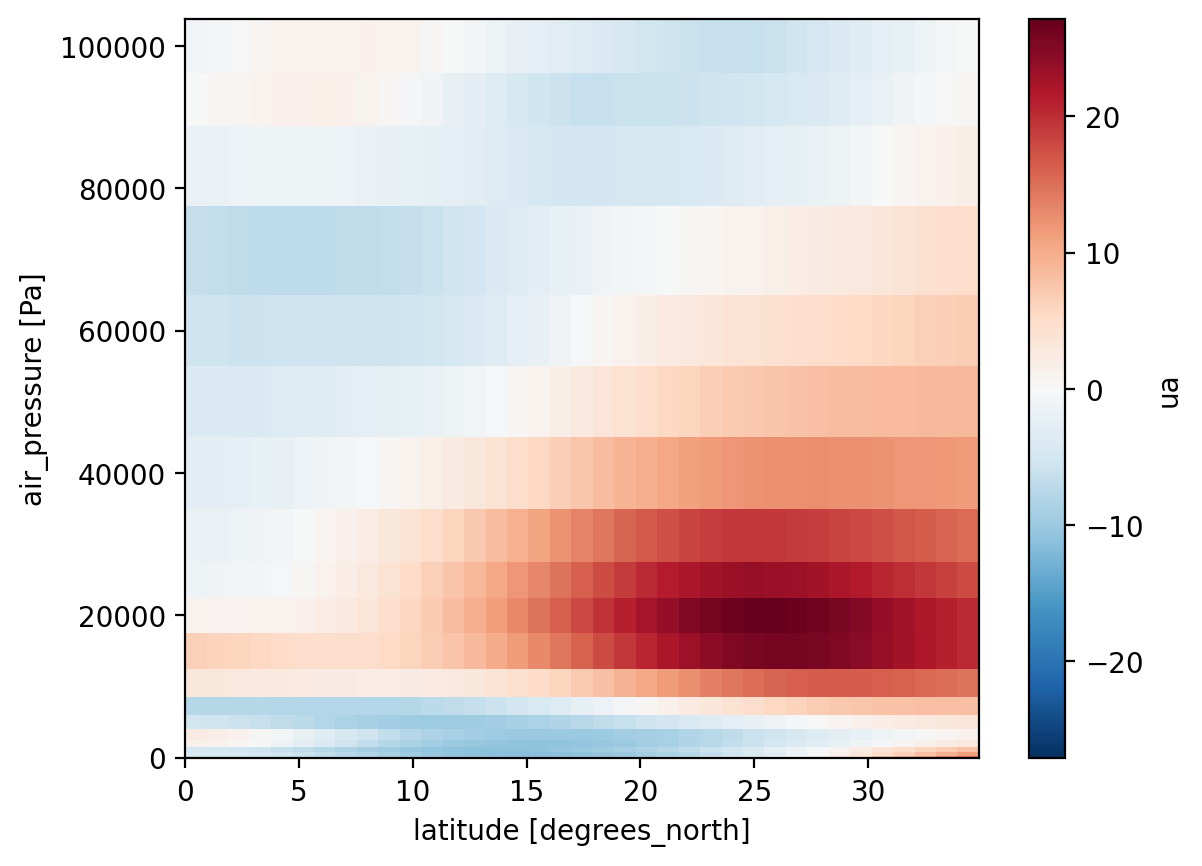

In [105]:
waccm_hist_u.mean('time').plot()